<a href="https://colab.research.google.com/github/dwgupta/dg_git_repo/blob/main/Tokenization_vectorization_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔤 Notebook 0: Tokenization & Vectorization — The Complete Picture

**Why this notebook exists:** Before a model can "understand" text, it needs to convert human language into numbers. This notebook answers the questions that trip everyone up:

- **Why** do we tokenize? Why not just use characters or whole words?
- **How** does BPE (Byte-Pair Encoding) actually work?
- **What** are vectors/embeddings and why do they capture meaning?
- **What** is the difference between static and contextual embeddings?
- **What** shape are these vectors and why does it matter?
- **When** does tokenization and vectorization happen — training, inference, or both?

Every concept comes with **runnable code** and **visualizations**.

---

In [1]:
# === SETUP ===
# Install required libraries (run this cell first)
!pip install tiktoken transformers torch numpy matplotlib scikit-learn plotly -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter, defaultdict
import re

np.random.seed(42)
print("✅ Setup complete!")

✅ Setup complete!


---

# PART 1: TOKENIZATION

## 1.1 The Problem: Computers Don't Read Text

A neural network is just matrix multiplications. It needs **numbers**, not letters. So we need a strategy to break text into pieces and assign each piece a number.

But HOW we break text up matters a LOT. Let's see why.

In [2]:
# === THREE STRATEGIES FOR BREAKING TEXT INTO PIECES ===

text = "The cats are playing unhappily"

# --- Strategy 1: Character-level ---
# Split into individual characters
char_tokens = list(text)

# --- Strategy 2: Word-level ---
# Split on spaces
word_tokens = text.split()

# --- Strategy 3: Subword (BPE-style) ---
# Split into meaningful pieces — this is what modern LLMs use
subword_tokens = ["The", " cats", " are", " play", "ing", " un", "happ", "ily"]

print("The sentence: \"{}\"".format(text))
print()
print(f"Strategy 1 — Character-level ({len(char_tokens)} tokens):")
print(f"  {char_tokens}")
print()
print(f"Strategy 2 — Word-level ({len(word_tokens)} tokens):")
print(f"  {word_tokens}")
print()
print(f"Strategy 3 — Subword/BPE ({len(subword_tokens)} tokens):")
print(f"  {subword_tokens}")

The sentence: "The cats are playing unhappily"

Strategy 1 — Character-level (30 tokens):
  ['T', 'h', 'e', ' ', 'c', 'a', 't', 's', ' ', 'a', 'r', 'e', ' ', 'p', 'l', 'a', 'y', 'i', 'n', 'g', ' ', 'u', 'n', 'h', 'a', 'p', 'p', 'i', 'l', 'y']

Strategy 2 — Word-level (5 tokens):
  ['The', 'cats', 'are', 'playing', 'unhappily']

Strategy 3 — Subword/BPE (8 tokens):
  ['The', ' cats', ' are', ' play', 'ing', ' un', 'happ', 'ily']


============================================================
PROBLEM WITH CHARACTER-LEVEL TOKENIZATION
============================================================

Sentence: 'The cat sat on the mat'
  - As characters: 22 tokens
  - As words:      6 tokens

Problem 1: SEQUENCE LENGTH EXPLODES
  - A 500-word essay ≈ 3,000 characters, Attention is O(n²), so 3000² = 9,000,000 operations vs 500² = 250,000 operations with word-level tokens
  - That's 36x more computation!

Problem 2: HARDER TO LEARN MEANING
  - The model must learn that 'c' + 'a' + 't' = the concept of a cat
  - That's a LOT of work compared to seeing 'cat' as one unit

Small vocab though! Only ~256 possible characters (ASCII/UTF-8 bytes)

============================================================
PROBLEM WITH WORD-LEVEL TOKENIZATION
============================================================

Problem 1: VOCABULARY EXPLODES
  - English has ~170,000 words in current use
  - Add names, code, URLs, typos, slang...
  - You'd need millions of entries in your vocab
  - Each entry = a row in the embedding matrix = huge memory

Problem 2: CAN'T HANDLE UNKNOWN WORDS
  - What does the model do with: ['ChatGPT', 'defenestration', 'vibes', 'covfefe', 'Björk']?
  - If they're not in the vocab → <UNK> token → lost information

Problem 3: MISSES MORPHOLOGICAL RELATIONSHIPS
  - 'play', 'playing', 'played', 'plays', 'player', 'playful'
  - These are 6 SEPARATE vocab entries with no shared structure, But they all share the root 'play'!
  - A subword tokenizer captures this: 'play' + 'ing', 'play' + 'ed', etc.

============================================================
SUBWORD TOKENIZATION — THE BEST OF BOTH WORLDS
============================================================

- ✅ Manageable vocabulary size (~30K to 100K tokens)
- ✅ Short sequences (not as bloated as character-level)
- ✅ Can handle ANY text (unknown words → broken into known subwords)
- ✅ Captures morphology ('play' + 'ing' shares 'play' with 'play' + 'ed')
- ✅ Common words stay whole ('the', 'and', 'is' = single tokens)
- ✅ Rare words get split into pieces ('unhappily' → 'un' + 'happ' + 'ily')

This is what GPT, BERT, Claude, Llama, and all modern LLMs use.
The most common algorithm: BPE (Byte-Pair Encoding)

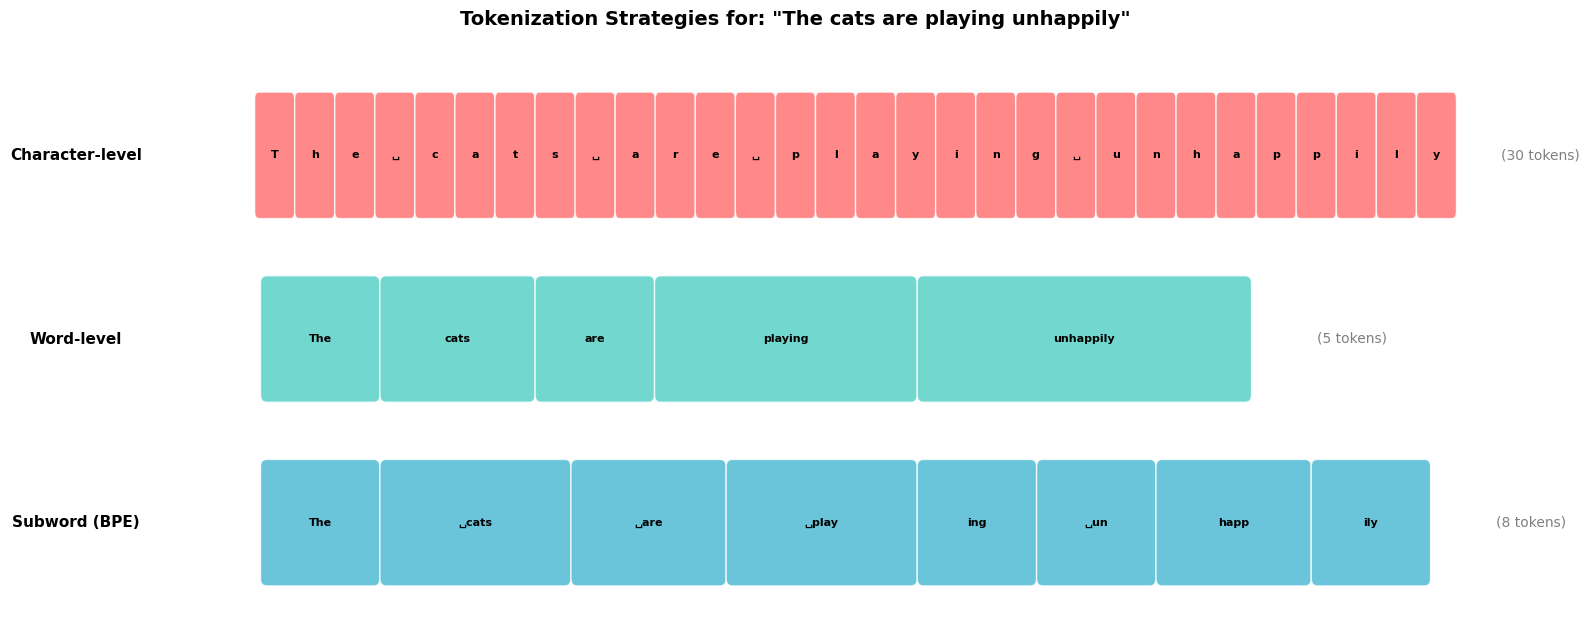

In [3]:
# === VISUAL COMPARISON ===

text = "The cats are playing unhappily"

strategies = {
    "Character-level": list(text),
    "Word-level": text.split(),
    "Subword (BPE)": ["The", " cats", " are", " play", "ing", " un", "happ", "ily"],
}

fig, axes = plt.subplots(3, 1, figsize=(16, 6))

colors_map = {
    "Character-level": "#FF6B6B",
    "Word-level": "#4ECDC4",
    "Subword (BPE)": "#45B7D1"
}

for ax, (name, tokens) in zip(axes, strategies.items()):
    color = colors_map[name]
    x_pos = 0
    for i, token in enumerate(tokens):
        display_token = token.replace(" ", "␣")  # make spaces visible
        width = max(len(display_token) * 0.3, 0.4)
        rect = mpatches.FancyBboxPatch(
            (x_pos, 0.1), width, 0.8,
            boxstyle="round,pad=0.05",
            facecolor=color, edgecolor='white', alpha=0.8
        )
        ax.add_patch(rect)
        ax.text(x_pos + width/2, 0.5, display_token,
                ha='center', va='center', fontsize=8, fontweight='bold')
        x_pos += width + 0.1

    ax.set_xlim(-0.2, max(x_pos, 10))
    ax.set_ylim(-0.1, 1.1)
    ax.set_ylabel(name, fontsize=11, fontweight='bold', rotation=0, labelpad=120, va='center')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.text(x_pos + 0.5, 0.5, f"({len(tokens)} tokens)", fontsize=10, va='center', color='gray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.suptitle(f'Tokenization Strategies for: "{text}"', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/tokenization_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 1.2 BPE (Byte-Pair Encoding) — How It Actually Works

BPE starts with individual characters and **iteratively merges** the most frequent pair. It's beautifully simple.

Let's implement it from scratch and watch it learn.

In [ ]:
# === BPE FROM SCRATCH ===

class BPETokenizer:
    """
    A minimal Byte-Pair Encoding tokenizer.

    The algorithm:
    1. Start: every character is its own token
    2. Count all adjacent token pairs in the training data
    3. Find the most frequent pair
    4. Merge that pair into a new single token
    5. Repeat steps 2-4 for N iterations (N = desired vocab size - initial chars)

    This is EXACTLY how GPT's tokenizer was built (with some optimizations).
    """

    def __init__(self):
        self.merges = {}          # stores learned merge rules: (a, b) → "ab"
        self.vocab = {}           # token → id mapping
        self.reverse_vocab = {}   # id → token mapping
        self.merge_history = []   # for visualization

    def _get_pairs(self, token_list):
        """
        Count frequency of adjacent pairs in the tokenized corpus.

        Example: ['t', 'h', 'e', ' ', 'c', 'a', 't']
        Pairs: ('t','h'), ('h','e'), ('e',' '), (' ','c'), ('c','a'), ('a','t')
        """
        pairs = Counter()
        for word_tokens in token_list:
            for i in range(len(word_tokens) - 1):
                pairs[(word_tokens[i], word_tokens[i + 1])] += 1
        return pairs

    def _merge_pair(self, token_list, pair):
        """
        Merge all occurrences of a pair in the corpus.

        Example: merge ('t', 'h') in ['t', 'h', 'e'] → ['th', 'e']
        """
        new_token_list = []
        for word_tokens in token_list:
            new_word = []
            i = 0
            while i < len(word_tokens):
                # If we find the pair, merge it
                if (i < len(word_tokens) - 1 and
                    word_tokens[i] == pair[0] and
                    word_tokens[i + 1] == pair[1]):
                    new_word.append(pair[0] + pair[1])  # merge into one token
                    i += 2  # skip both original tokens
                else:
                    new_word.append(word_tokens[i])
                    i += 1
            new_token_list.append(new_word)
        return new_token_list

    def train(self, text, num_merges=20, verbose=True):
        """
        Learn BPE merge rules from training text.

        This happens ONCE during training. The learned merges are then
        used for both training and inference tokenization.
        """
        # Step 1: Split text into words, then each word into characters
        words = text.split()
        # Add a special end-of-word marker so we know where words end
        token_list = [list(word) + ['</w>'] for word in words]

        if verbose:
            print("Initial tokenization (each character is a token):")
            flat = [t for word in token_list for t in word]
            print(f"  {flat[:30]}...")
            print(f"  Unique tokens: {len(set(flat))}")
            print()

        # Step 2: Iteratively merge most frequent pairs
        for step in range(num_merges):
            # Count all adjacent pairs
            pairs = self._get_pairs(token_list)

            if not pairs:
                break

            # Find the most frequent pair
            best_pair = max(pairs, key=pairs.get)
            best_count = pairs[best_pair]

            # Merge it everywhere in the corpus
            token_list = self._merge_pair(token_list, best_pair)

            # Save the merge rule
            merged_token = best_pair[0] + best_pair[1]
            self.merges[best_pair] = merged_token

            # Track history for visualization
            all_tokens = set(t for word in token_list for t in word)
            self.merge_history.append({
                'step': step + 1,
                'pair': best_pair,
                'merged': merged_token,
                'count': best_count,
                'vocab_size': len(all_tokens),
                'example': [t for word in token_list[:3] for t in word]
            })

            if verbose:
                print(f"  Merge {step+1:2d}: '{best_pair[0]}' + '{best_pair[1]}' → "
                      f"'{merged_token}' (appeared {best_count} times)")

        # Build vocabulary from all tokens that appear after merging
        all_tokens = sorted(set(t for word in token_list for t in word))
        self.vocab = {token: i for i, token in enumerate(all_tokens)}
        self.reverse_vocab = {i: token for token, i in self.vocab.items()}

        if verbose:
            print(f"\nFinal vocabulary size: {len(self.vocab)}")
            print(f"Final vocabulary: {list(self.vocab.keys())}")

        return token_list

    def encode(self, text):
        """
        Tokenize new text using learned merge rules.

        This is used at BOTH training and inference time.
        Same merge rules, applied to any new text.
        """
        words = text.split()
        all_tokens = []

        for word in words:
            # Start with characters
            tokens = list(word) + ['</w>']

            # Apply merges in the order they were learned
            for pair, merged in self.merges.items():
                new_tokens = []
                i = 0
                while i < len(tokens):
                    if (i < len(tokens) - 1 and
                        tokens[i] == pair[0] and
                        tokens[i+1] == pair[1]):
                        new_tokens.append(merged)
                        i += 2
                    else:
                        new_tokens.append(tokens[i])
                        i += 1
                tokens = new_tokens

            all_tokens.extend(tokens)

        # Convert to IDs
        ids = [self.vocab.get(t, 0) for t in all_tokens]
        return all_tokens, ids


print("BPETokenizer class ready! Let's train it...")

BPETokenizer class ready! Let's train it...


In [ ]:
# === TRAIN BPE ON A SMALL CORPUS ===

corpus = (
    "the cat sat on the mat "
    "the cat chased the rat "
    "the dog sat on the log "
    "the dog chased the cat "
    "the rat sat on the hat "
    "the cat and the dog sat "
    "the cat sat and the rat sat"
)

bpe = BPETokenizer()
print("Training BPE on corpus...")
print("=" * 60)
final_tokens = bpe.train(corpus, num_merges=25)

Training BPE on corpus...
Initial tokenization (each character is a token):
  ['t', 'h', 'e', '</w>', 'c', 'a', 't', '</w>', 's', 'a', 't', '</w>', 'o', 'n', '</w>', 't', 'h', 'e', '</w>', 'm', 'a', 't', '</w>', 't', 'h', 'e', '</w>', 'c', 'a', 't']...
  Unique tokens: 14

  Merge  1: 'a' + 't' → 'at' (appeared 16 times)
  Merge  2: 'at' + '</w>' → 'at</w>' (appeared 16 times)
  Merge  3: 't' + 'h' → 'th' (appeared 14 times)
  Merge  4: 'th' + 'e' → 'the' (appeared 14 times)
  Merge  5: 'the' + '</w>' → 'the</w>' (appeared 14 times)
  Merge  6: 's' + 'at</w>' → 'sat</w>' (appeared 6 times)
  Merge  7: 'c' + 'at</w>' → 'cat</w>' (appeared 5 times)
  Merge  8: 'd' + '</w>' → 'd</w>' (appeared 4 times)
  Merge  9: 'o' + 'g' → 'og' (appeared 4 times)
  Merge 10: 'og' + '</w>' → 'og</w>' (appeared 4 times)
  Merge 11: 'o' + 'n' → 'on' (appeared 3 times)
  Merge 12: 'on' + '</w>' → 'on</w>' (appeared 3 times)
  Merge 13: 'r' + 'at</w>' → 'rat</w>' (appeared 3 times)
  Merge 14: 'd' + 'og</w>

/tmp/ipykernel_960/1484916694.py:177: UserWarning: Glyph 9141 (\N{BOTTOM SQUARE BRACKET}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_960/1484916694.py:177: UserWarning: Glyph 9141 (\N{BOTTOM SQUARE BRACKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_960/1484916694.py:178: UserWarning: Glyph 9141 (\N{BOTTOM SQUARE BRACKET}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('/tmp/bpe_training.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_960/1484916694.py:178: UserWarning: Glyph 9141 (\N{BOTTOM SQUARE BRACKET}) missing from font(s) DejaVu Sans.
  plt.savefig('/tmp/bpe_training.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9141 (\N{BOTTOM SQUARE BRACKET}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9141 (\N{BOTTOM SQ

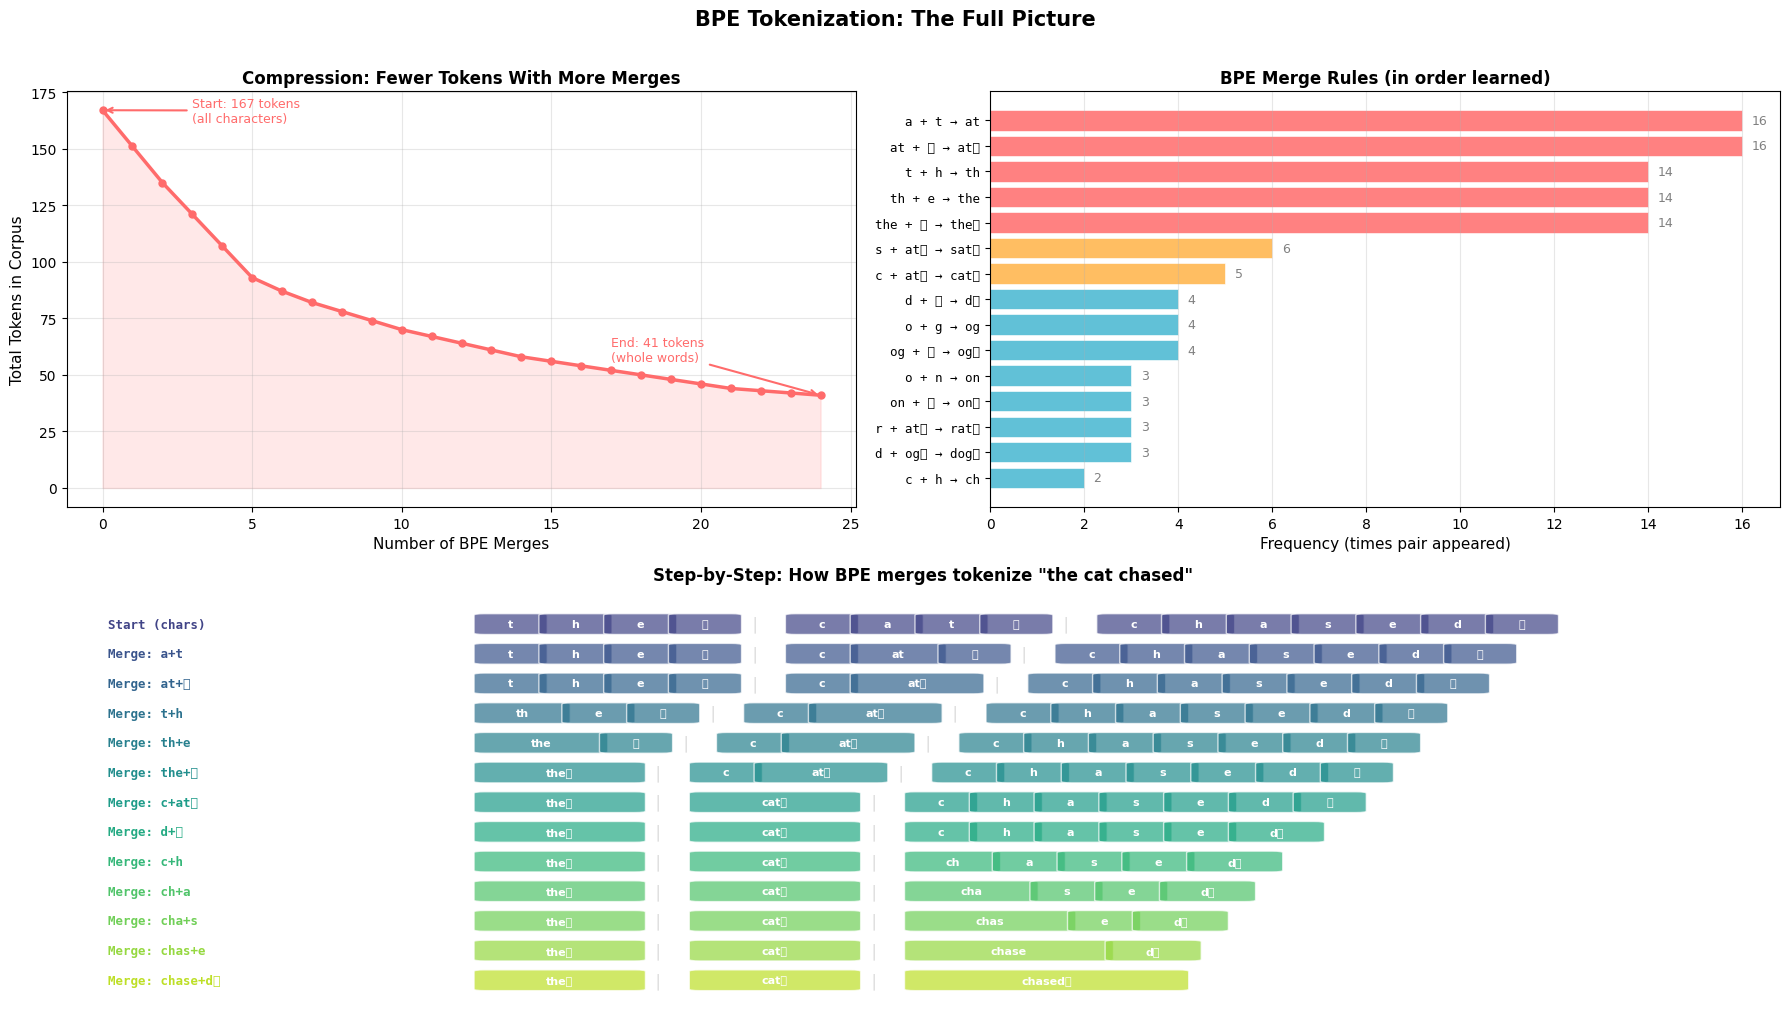

→ TOP LEFT: Each merge compresses the corpus. Fewer total tokens = more efficient.
  Started at 167 tokens (characters), ended at 41 (whole words).
→ TOP RIGHT: Most frequent pairs get merged first ('a'+'t', 't'+'h').
→ BOTTOM: Watch 'the cat chased' go from characters to whole words step by step.


In [ ]:
# === VISUALIZE THE BPE MERGE PROCESS ===
# Let's show: (1) how tokens-per-word shrinks, (2) merge frequency, (3) step-by-step example

fig = plt.figure(figsize=(18, 10))

# --- PANEL 1 (top-left): Average tokens per word decreases with more merges ---
# This is the key intuition: more merges → fewer tokens needed to represent the corpus
ax1 = fig.add_subplot(2, 2, 1)

# Recompute: retrain BPE step by step and count total tokens at each step
corpus_for_viz = (
    "the cat sat on the mat "
    "the cat chased the rat "
    "the dog sat on the log "
    "the dog chased the cat "
    "the rat sat on the hat "
    "the cat and the dog sat "
    "the cat sat and the rat sat"
)
words_viz = corpus_for_viz.split()

# Count total tokens in the corpus at each merge step
token_list_viz = [list(word) + ['</w>'] for word in words_viz]
total_tokens_per_step = [sum(len(w) for w in token_list_viz)]  # step 0

# Replay merges
for h in bpe.merge_history:
    pair = h['pair']
    new_list = []
    for word_tokens in token_list_viz:
        new_word = []
        i = 0
        while i < len(word_tokens):
            if (i < len(word_tokens) - 1 and
                word_tokens[i] == pair[0] and
                word_tokens[i + 1] == pair[1]):
                new_word.append(pair[0] + pair[1])
                i += 2
            else:
                new_word.append(word_tokens[i])
                i += 1
        new_list.append(new_word)
    token_list_viz = new_list
    total_tokens_per_step.append(sum(len(w) for w in token_list_viz))

ax1.plot(range(len(total_tokens_per_step)), total_tokens_per_step,
         'o-', color='#FF6B6B', linewidth=2.5, markersize=5)
ax1.fill_between(range(len(total_tokens_per_step)), total_tokens_per_step,
                 alpha=0.15, color='#FF6B6B')
ax1.set_xlabel('Number of BPE Merges', fontsize=11)
ax1.set_ylabel('Total Tokens in Corpus', fontsize=11)
ax1.set_title('Compression: Fewer Tokens With More Merges', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.annotate(f'Start: {total_tokens_per_step[0]} tokens\n(all characters)',
             xy=(0, total_tokens_per_step[0]),
             xytext=(3, total_tokens_per_step[0] - 5),
             fontsize=9, color='#FF6B6B',
             arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=1.5))
ax1.annotate(f'End: {total_tokens_per_step[-1]} tokens\n(whole words)',
             xy=(len(total_tokens_per_step)-1, total_tokens_per_step[-1]),
             xytext=(len(total_tokens_per_step)-8, total_tokens_per_step[-1] + 15),
             fontsize=9, color='#FF6B6B',
             arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=1.5))


# --- PANEL 2 (top-right): Merge frequency (horizontal bar chart) ---
ax2 = fig.add_subplot(2, 2, 2)

merge_labels = []
merge_counts = []
for h in bpe.merge_history[:15]:
    p0 = h['pair'][0].replace('</w>', '⎵')
    p1 = h['pair'][1].replace('</w>', '⎵')
    merged = h['merged'].replace('</w>', '⎵')
    merge_labels.append(f'{p0} + {p1} → {merged}')
    merge_counts.append(h['count'])

colors_bar = ['#FF6B6B' if c >= 10 else '#FFB347' if c >= 5 else '#45B7D1'
              for c in merge_counts]
bars = ax2.barh(range(len(merge_labels)), merge_counts, color=colors_bar, alpha=0.85,
                edgecolor='white', linewidth=0.5)
ax2.set_yticks(range(len(merge_labels)))
ax2.set_yticklabels(merge_labels, fontsize=9, fontfamily='monospace')
ax2.set_xlabel('Frequency (times pair appeared)', fontsize=11)
ax2.set_title('BPE Merge Rules (in order learned)', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, merge_counts)):
    ax2.text(bar.get_width() + 0.2, i, str(count), va='center', fontsize=9, color='gray')


# --- PANEL 3 (bottom, full width): Step-by-step tokenization of one word ---
ax3 = fig.add_subplot(2, 1, 2)

# Show how 'the cat chased' gets tokenized step by step
example_word_list = [list('the') + ['</w>'], list('cat') + ['</w>'], list('chased') + ['</w>']]
step_snapshots = []
step_labels_list = ['Start (chars)']

# Initial state
flat_initial = []
for w in example_word_list:
    flat_initial.extend(w)
    flat_initial.append(' | ')  # word separator for display
step_snapshots.append(flat_initial[:-1])  # remove trailing separator

# Apply each merge
for h in bpe.merge_history:
    pair = h['pair']
    changed = False
    new_list = []
    for word_tokens in example_word_list:
        new_word = []
        i = 0
        while i < len(word_tokens):
            if (i < len(word_tokens) - 1 and
                word_tokens[i] == pair[0] and
                word_tokens[i + 1] == pair[1]):
                new_word.append(pair[0] + pair[1])
                i += 2
                changed = True
            else:
                new_word.append(word_tokens[i])
                i += 1
        new_list.append(new_word)
    example_word_list = new_list

    if changed:
        flat = []
        for w in example_word_list:
            flat.extend(w)
            flat.append(' | ')
        step_snapshots.append(flat[:-1])
        p0 = pair[0].replace('</w>', '⎵')
        p1 = pair[1].replace('</w>', '⎵')
        step_labels_list.append(f'Merge: {p0}+{p1}')

# Draw the step-by-step visualization
num_steps = len(step_snapshots)
step_colors = plt.cm.viridis(np.linspace(0.2, 0.9, num_steps))

for row, (snapshot, label, color) in enumerate(zip(step_snapshots, step_labels_list, step_colors)):
    y = num_steps - row - 1
    x_pos = 1.8  # start after label

    # Draw label
    ax3.text(0, y, label, fontsize=9, va='center', ha='left',
            fontweight='bold', color=color, fontfamily='monospace')

    for token in snapshot:
        display = token.replace('</w>', '⎵')
        if token == ' | ':
            ax3.text(x_pos + 0.05, y, '│', fontsize=10, va='center', ha='center', color='lightgray')
            x_pos += 0.25
            continue

        width = max(len(display) * 0.18, 0.25)
        rect = mpatches.FancyBboxPatch(
            (x_pos, y - 0.3), width, 0.6,
            boxstyle='round,pad=0.05',
            facecolor=color, edgecolor='white', alpha=0.7
        )
        ax3.add_patch(rect)
        ax3.text(x_pos + width/2, y, display, fontsize=8, va='center', ha='center',
                fontweight='bold', color='white')
        x_pos += width + 0.06

ax3.set_xlim(-0.2, 8)
ax3.set_ylim(-0.8, num_steps + 0.2)
ax3.set_title('Step-by-Step: How BPE merges tokenize "the cat chased"',
              fontsize=12, fontweight='bold')
ax3.axis('off')

plt.suptitle('BPE Tokenization: The Full Picture', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/bpe_training.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ TOP LEFT: Each merge compresses the corpus. Fewer total tokens = more efficient.")
print("  Started at", total_tokens_per_step[0], "tokens (characters), ended at", total_tokens_per_step[-1], "(whole words).")
print("→ TOP RIGHT: Most frequent pairs get merged first ('a'+'t', 't'+'h').")
print("→ BOTTOM: Watch 'the cat chased' go from characters to whole words step by step.")

In [ ]:
# === ENCODE NEW TEXT WITH OUR TRAINED BPE ===

test_sentences = [
    "the cat sat",           # all common words — will be highly merged
    "the rat chased",        # familiar words
    "the fox jumped",        # 'fox' and 'jumped' are UNSEEN — watch how BPE handles them
]

print("Encoding new text with learned BPE merges:")
print("=" * 60)
for sent in test_sentences:
    tokens, ids = bpe.encode(sent)
    print(f"\n  Text:   '{sent}'")
    print(f"  Tokens: {tokens}")
    print(f"  IDs:    {ids}")

print("\n→ Notice: 'fox' gets split into characters because it was never in training data.")
print("  But 'the' and 'cat' became single tokens because they were common!")
print("  This is why BPE can handle ANY input — worst case, it falls back to characters.")

Encoding new text with learned BPE merges:

  Text:   'the cat sat'
  Tokens: ['the</w>', 'cat</w>', 'sat</w>']
  IDs:    [10, 1, 9]

  Text:   'the rat chased'
  Tokens: ['the</w>', 'rat</w>', 'chased</w>']
  IDs:    [10, 8, 2]

  Text:   'the fox jumped'
  Tokens: ['the</w>', 'f', 'o', 'x', '</w>', 'j', 'u', 'm', 'p', 'e', 'd</w>']
  IDs:    [10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

→ Notice: 'fox' gets split into characters because it was never in training data.
  But 'the' and 'cat' became single tokens because they were common!
  This is why BPE can handle ANY input — worst case, it falls back to characters.


---

## 1.3 Real-World Tokenizers: tiktoken (GPT) and Hugging Face (BERT)

Let's see how actual production tokenizers work. Same BPE idea, just trained on massive data with optimizations.

In [ ]:
# === TIKTOKEN — The tokenizer used by GPT-3.5, GPT-4 ===

import tiktoken

# Load the GPT-4 tokenizer
enc = tiktoken.encoding_for_model("gpt-4")

print(f"GPT-4 Tokenizer: cl100k_base")
print(f"Vocabulary size: ~100,000 tokens")
print()

# Tokenize various examples
examples = [
    "Hello world",
    "The cats are playing unhappily",
    "I love artificial intelligence",
    "supercalifragilisticexpialidocious",
    "def fibonacci(n): return n if n < 2 else fibonacci(n-1) + fibonacci(n-2)",
    "こんにちは世界",           # Japanese
    "🎉🤖💡",                   # Emojis
]

print("How GPT-4 tokenizes different inputs:")
print("-" * 70)

for text in examples:
    token_ids = enc.encode(text)
    # Decode each token individually to see the pieces
    token_strings = [enc.decode([tid]) for tid in token_ids]

    print(f"\n  Text:   '{text}'")
    print(f"  Tokens: {token_strings}")
    print(f"  IDs:    {token_ids}")
    print(f"  Count:  {len(token_ids)} tokens")

GPT-4 Tokenizer: cl100k_base
Vocabulary size: ~100,000 tokens

How GPT-4 tokenizes different inputs:
----------------------------------------------------------------------

  Text:   'Hello world'
  Tokens: ['Hello', ' world']
  IDs:    [9906, 1917]
  Count:  2 tokens

  Text:   'The cats are playing unhappily'
  Tokens: ['The', ' cats', ' are', ' playing', ' unh', 'app', 'ily']
  IDs:    [791, 19987, 527, 5737, 31175, 680, 1570]
  Count:  7 tokens

  Text:   'I love artificial intelligence'
  Tokens: ['I', ' love', ' artificial', ' intelligence']
  IDs:    [40, 3021, 21075, 11478]
  Count:  4 tokens

  Text:   'supercalifragilisticexpialidocious'
  Tokens: ['sup', 'erc', 'al', 'if', 'rag', 'il', 'istic', 'exp', 'ial', 'id', 'ocious']
  IDs:    [13066, 3035, 278, 333, 4193, 321, 4633, 4683, 532, 307, 78287]
  Count:  11 tokens

  Text:   'def fibonacci(n): return n if n < 2 else fibonacci(n-1) + fibonacci(n-2)'
  Tokens: ['def', ' fibonacci', '(n', '):', ' return', ' n', ' if', ' n', '

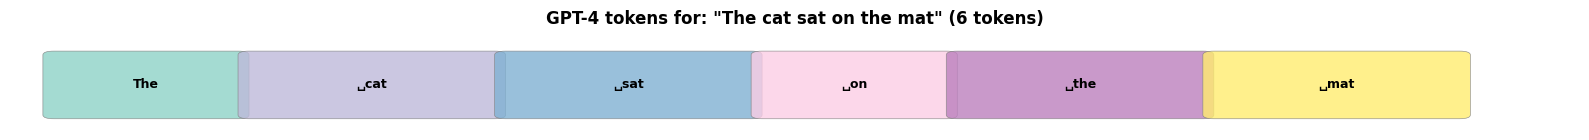

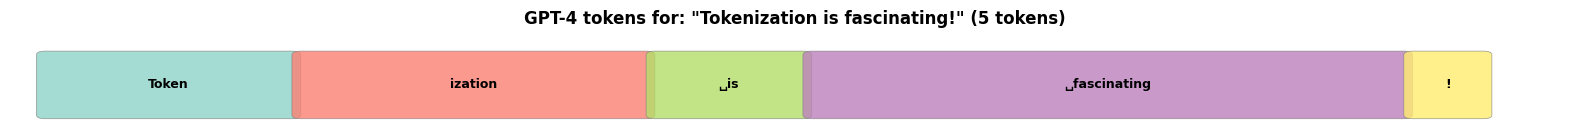

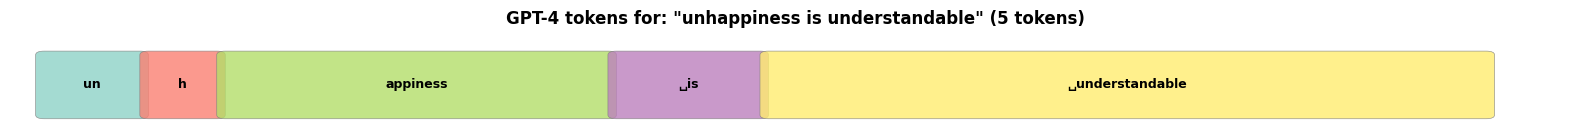

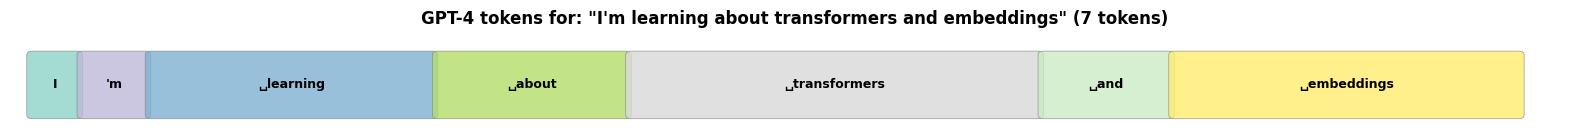


→ Notice how common words are single tokens ('The', ' cat', ' sat')
  but rarer words get split ('Tokenization' → 'Token' + 'ization')
  Also notice: spaces are often PART of the token (leading space).


In [ ]:
# === VISUALIZE TOKEN BOUNDARIES ===
# This helps you SEE where the tokenizer splits text

def visualize_tokens(text, encoder, title=""):
    """
    Color-code each token in a sentence to show token boundaries.
    """
    token_ids = encoder.encode(text)
    token_strings = [encoder.decode([tid]) for tid in token_ids]

    # Generate distinct colors for each token
    colors = plt.cm.Set3(np.linspace(0, 1, max(len(token_strings), 1)))

    fig, ax = plt.subplots(figsize=(16, 1.5))

    x_pos = 0
    for i, (token_str, color) in enumerate(zip(token_strings, colors)):
        display = token_str.replace("\n", "↵").replace(" ", "␣")
        width = max(len(display) * 0.28, 0.4)

        rect = mpatches.FancyBboxPatch(
            (x_pos, 0.1), width, 0.8,
            boxstyle="round,pad=0.05",
            facecolor=color, edgecolor='gray', alpha=0.8, linewidth=0.5
        )
        ax.add_patch(rect)
        ax.text(x_pos + width/2, 0.5, display,
                ha='center', va='center', fontsize=9, fontweight='bold')
        x_pos += width + 0.05

    ax.set_xlim(-0.2, x_pos + 0.5)
    ax.set_ylim(-0.1, 1.2)
    ax.set_title(f"{title} ({len(token_strings)} tokens)", fontsize=12, fontweight='bold')
    ax.axis('off')
    return fig


sentences = [
    "The cat sat on the mat",
    "Tokenization is fascinating!",
    "unhappiness is understandable",
    "I'm learning about transformers and embeddings",
]

for sent in sentences:
    fig = visualize_tokens(sent, enc, title=f"GPT-4 tokens for: \"{sent}\"")
    plt.tight_layout()
    plt.show()

print("\n→ Notice how common words are single tokens ('The', ' cat', ' sat')")
print("  but rarer words get split ('Tokenization' → 'Token' + 'ization')")
print("  Also notice: spaces are often PART of the token (leading space).")

In [ ]:
# === COMPARING TOKENIZERS: GPT-4 vs BERT ===

from transformers import AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "The cats are playing unhappily in the garden"

# GPT-4 tokenization (BPE)
gpt_ids = enc.encode(text)
gpt_tokens = [enc.decode([tid]) for tid in gpt_ids]

# BERT tokenization (WordPiece — similar to BPE but slightly different algorithm)
bert_output = bert_tokenizer(text, add_special_tokens=True)
bert_tokens = bert_tokenizer.convert_ids_to_tokens(bert_output['input_ids'])

print(f"Text: '{text}'")
print()
print(f"GPT-4 (BPE):         {gpt_tokens}")
print(f"  Token count:       {len(gpt_tokens)}")
print(f"  Vocab size:        ~100,000")
print()
print(f"BERT (WordPiece):    {bert_tokens}")
print(f"  Token count:       {len(bert_tokens)}")
print(f"  Vocab size:        30,522")
print()
print("Key differences:")
print("  - BERT adds [CLS] at start and [SEP] at end (special tokens)")
print("  - BERT lowercases everything (uncased model)")
print("  - BERT uses ## prefix for word continuations ('un' + '##happi' + '##ly')")
print("  - GPT uses leading spaces as part of tokens")
print("  - Different vocab sizes → different splits")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Text: 'The cats are playing unhappily in the garden'

GPT-4 (BPE):         ['The', ' cats', ' are', ' playing', ' unh', 'app', 'ily', ' in', ' the', ' garden']
  Token count:       10
  Vocab size:        ~100,000

BERT (WordPiece):    ['[CLS]', 'the', 'cats', 'are', 'playing', 'un', '##ha', '##pp', '##ily', 'in', 'the', 'garden', '[SEP]']
  Token count:       13
  Vocab size:        30,522

Key differences:
  - BERT adds [CLS] at start and [SEP] at end (special tokens)
  - BERT lowercases everything (uncased model)
  - BERT uses ## prefix for word continuations ('un' + '##happi' + '##ly')
  - GPT uses leading spaces as part of tokens
  - Different vocab sizes → different splits


In [ ]:
# === INTERESTING TOKENIZATION EDGE CASES ===
# These illustrate why understanding tokenization matters for prompt engineering

print("Surprising tokenization behaviors (GPT-4):")
print("=" * 60)

edge_cases = [
    ("      ", "Multiple spaces"),
    ("\n\n\n", "Newlines"),
    ("123456789", "Numbers"),
    ("$1,234.56", "Currency"),
    ("don't won't I'm", "Contractions"),
    ("https://www.example.com/path?q=hello", "URL"),
    ("print('Hello, World!')", "Code"),
    ("AAAAAAaaaaaa", "Repeated characters"),
]

for text, description in edge_cases:
    ids = enc.encode(text)
    tokens = [enc.decode([tid]) for tid in ids]
    # Make whitespace visible
    display_tokens = [t.replace(" ", "␣").replace("\n", "↵") for t in tokens]
    print(f"\n  {description}:")
    print(f"    Text:   '{text}'")
    print(f"    Tokens: {display_tokens}")
    print(f"    Count:  {len(tokens)}")

print("\n" + "=" * 60)
print("→ Numbers are often split into individual digits or small groups!")
print("  This is why LLMs struggle with math — '12345' isn't one number to them.")
print("→ Spaces and newlines consume tokens too — token-efficient prompting matters!")

Surprising tokenization behaviors (GPT-4):

  Multiple spaces:
    Text:   '      '
    Tokens: ['␣␣␣␣␣␣']
    Count:  1

  Newlines:
    Text:   '


'
    Tokens: ['↵↵↵']
    Count:  1

  Numbers:
    Text:   '123456789'
    Tokens: ['123', '456', '789']
    Count:  3

  Currency:
    Text:   '$1,234.56'
    Tokens: ['$', '1', ',', '234', '.', '56']
    Count:  6

  Contractions:
    Text:   'don't won't I'm'
    Tokens: ['don', "'t", '␣won', "'t", '␣I', "'m"]
    Count:  6

  URL:
    Text:   'https://www.example.com/path?q=hello'
    Tokens: ['https', '://', 'www', '.example', '.com', '/path', '?q', '=', 'hello']
    Count:  9

  Code:
    Text:   'print('Hello, World!')'
    Tokens: ['print', "('", 'Hello', ',', '␣World', '!', "')"]
    Count:  7

  Repeated characters:
    Text:   'AAAAAAaaaaaa'
    Tokens: ['AAAA', 'AA', 'aaaa', 'aa']
    Count:  4

→ Numbers are often split into individual digits or small groups!
  This is why LLMs struggle with math — '12345' isn't one number t

---

## 1.4 Token Counts and Cost — Why This Matters Practically

API pricing is per-token. Context windows are measured in tokens. Understanding token counts helps you:
- Estimate API costs
- Fit within context windows
- Write more efficient prompts

Token counts for different content types (GPT-4 tokenizer):
-----------------------------------------------------------------
  Short sentence       |   44 chars |  10 tokens | 4.4 chars/token
  English paragraph    |  257 chars |  42 tokens | 6.1 chars/token
  Python code          |  274 chars |  84 tokens | 3.3 chars/token
  JSON data            |   81 chars |  29 tokens | 2.8 chars/token

Rule of thumb for English: ~4 characters per token, or ~¾ of a word per token.
Code and structured data tend to use more tokens per character.


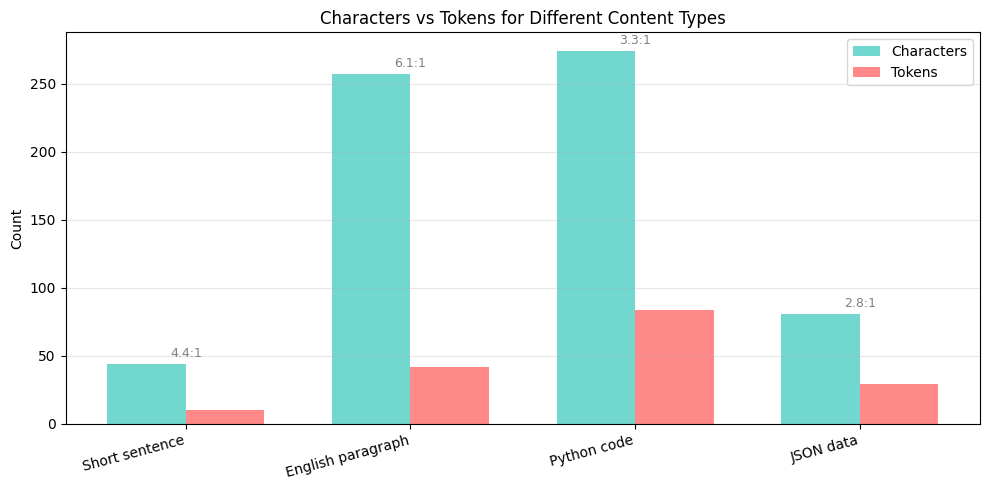

In [ ]:
# === TOKEN COUNTS FOR DIFFERENT CONTENT TYPES ===

content_samples = {
    "Short sentence": "The quick brown fox jumps over the lazy dog.",
    "English paragraph": (
        "Artificial intelligence has made remarkable progress in recent years. "
        "Large language models can now write code, translate languages, and engage "
        "in complex reasoning tasks. However, they still face challenges with "
        "mathematical reasoning and factual accuracy."
    ),
    "Python code": (
        "def quicksort(arr):\n"
        "    if len(arr) <= 1:\n"
        "        return arr\n"
        "    pivot = arr[len(arr) // 2]\n"
        "    left = [x for x in arr if x < pivot]\n"
        "    middle = [x for x in arr if x == pivot]\n"
        "    right = [x for x in arr if x > pivot]\n"
        "    return quicksort(left) + middle + quicksort(right)\n"
    ),
    "JSON data": '{"name": "John", "age": 30, "city": "New York", "hobbies": ["reading", "coding"]}',
}

print("Token counts for different content types (GPT-4 tokenizer):")
print("-" * 65)

names = []
char_counts = []
token_counts = []
ratios = []

for name, text in content_samples.items():
    num_tokens = len(enc.encode(text))
    num_chars = len(text)
    ratio = num_chars / num_tokens
    names.append(name)
    char_counts.append(num_chars)
    token_counts.append(num_tokens)
    ratios.append(ratio)
    print(f"  {name:20s} | {num_chars:4d} chars | {num_tokens:3d} tokens | {ratio:.1f} chars/token")

print()
print("Rule of thumb for English: ~4 characters per token, or ~¾ of a word per token.")
print("Code and structured data tend to use more tokens per character.")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, char_counts, width, label='Characters', color='#4ECDC4', alpha=0.8)
bars2 = ax.bar(x + width/2, token_counts, width, label='Tokens', color='#FF6B6B', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Count')
ax.set_title('Characters vs Tokens for Different Content Types')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add ratio labels
for i, ratio in enumerate(ratios):
    ax.text(i, max(char_counts[i], token_counts[i]) + 5, f"{ratio:.1f}:1",
            ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('/tmp/token_counts.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PART 2: VECTORIZATION (EMBEDDINGS)

We've converted text into token IDs (integers). But integers don't capture **meaning**.

Token ID 42 ("cat") and token ID 891 ("kitten") are just numbers — there's nothing that says they're related.

**Embeddings** solve this: they map each token to a **dense vector** (a list of numbers) where **similar tokens are close together** in this vector space.

---

## 2.1 What IS a Vector/Embedding?

An embedding is just a list of numbers that DESCRIBES a token. Each number represents some learned feature.

In [ ]:
# === THE INTUITION: Describing things with numbers ===

print("Imagine describing animals with just 4 numbers:")
print("  [size, domesticated, furry, aquatic]")
print()

# Hand-crafted "embeddings" to build intuition
animals = {
    #              size  domestic  furry  aquatic
    "cat":     [  0.3,    0.9,    0.9,    0.0 ],
    "dog":     [  0.5,    0.9,    0.8,    0.1 ],
    "kitten":  [  0.1,    0.9,    0.9,    0.0 ],
    "lion":    [  0.9,    0.0,    0.8,    0.0 ],
    "goldfish":[  0.05,   0.7,    0.0,    1.0 ],
    "whale":   [  1.0,    0.0,    0.0,    1.0 ],
    "hamster": [  0.05,   0.8,    0.9,    0.0 ],
}

for name, vec in animals.items():
    print(f"  {name:10s} → {vec}")

print("\nNow we can compute SIMILARITY between animals:")

def cosine_similarity(a, b):
    """How similar are two vectors? 1 = identical direction, 0 = unrelated, -1 = opposite."""
    a, b = np.array(a), np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

pairs = [("cat", "kitten"), ("cat", "dog"), ("cat", "lion"), ("cat", "whale"), ("goldfish", "whale")]
for a, b in pairs:
    sim = cosine_similarity(animals[a], animals[b])
    bar = "█" * int(sim * 20)
    print(f"  sim({a:8s}, {b:8s}) = {sim:.3f}  {bar}")

print("\n→ Cat-Kitten are very similar! Cat-Whale are very different!")
print("  In real embeddings, there are 768-12288 dimensions, not just 4.")
print("  And the features are LEARNED, not hand-crafted.")

Imagine describing animals with just 4 numbers:
  [size, domesticated, furry, aquatic]

  cat        → [0.3, 0.9, 0.9, 0.0]
  dog        → [0.5, 0.9, 0.8, 0.1]
  kitten     → [0.1, 0.9, 0.9, 0.0]
  lion       → [0.9, 0.0, 0.8, 0.0]
  goldfish   → [0.05, 0.7, 0.0, 1.0]
  whale      → [1.0, 0.0, 0.0, 1.0]
  hamster    → [0.05, 0.8, 0.9, 0.0]

Now we can compute SIMILARITY between animals:
  sim(cat     , kitten  ) = 0.988  ███████████████████
  sim(cat     , dog     ) = 0.982  ███████████████████
  sim(cat     , lion    ) = 0.629  ████████████
  sim(cat     , whale   ) = 0.162  ███
  sim(goldfish, whale   ) = 0.608  ████████████

→ Cat-Kitten are very similar! Cat-Whale are very different!
  In real embeddings, there are 768-12288 dimensions, not just 4.
  And the features are LEARNED, not hand-crafted.


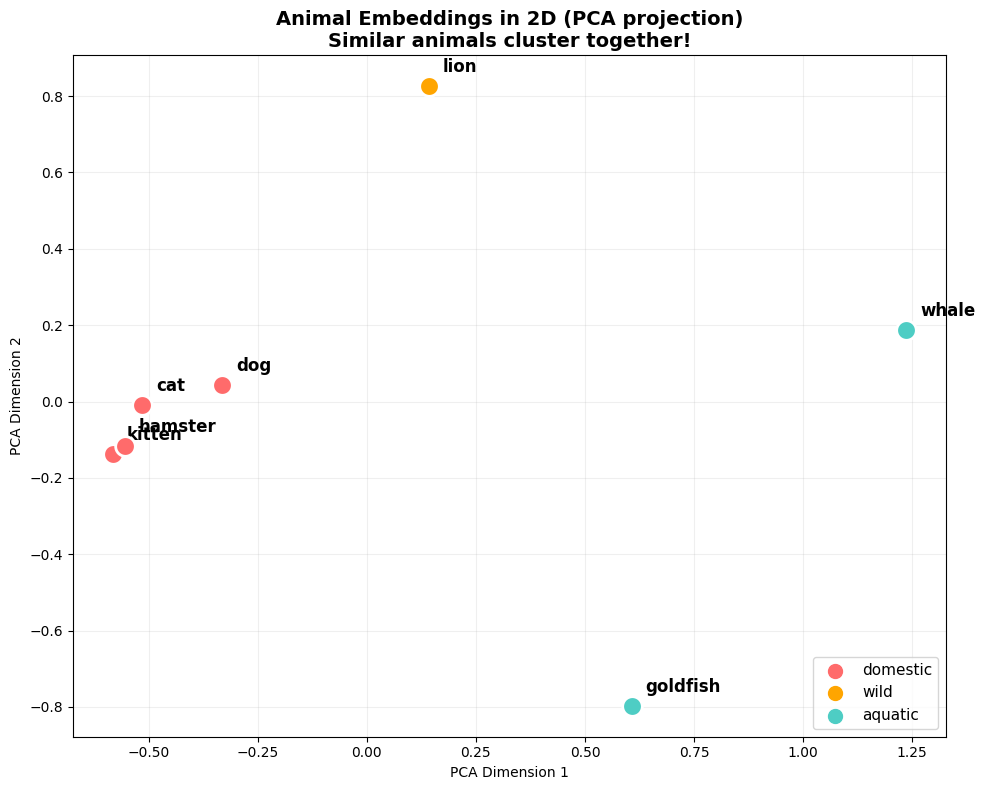

→ Similar animals are CLOSE in vector space.
  This is the whole point of embeddings!


In [ ]:
# === VISUALIZE THE ANIMAL EMBEDDINGS IN 2D ===

from sklearn.decomposition import PCA

names_list = list(animals.keys())
vectors = np.array(list(animals.values()))

# Reduce 4 dims to 2 for visualization
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(10, 8))

# Color by category
categories = {
    "cat": "domestic", "dog": "domestic", "kitten": "domestic",
    "hamster": "domestic", "lion": "wild", "goldfish": "aquatic", "whale": "aquatic"
}
cat_colors = {"domestic": "#FF6B6B", "wild": "#FFA500", "aquatic": "#4ECDC4"}

for i, name in enumerate(names_list):
    cat = categories[name]
    ax.scatter(vectors_2d[i, 0], vectors_2d[i, 1],
              c=cat_colors[cat], s=200, zorder=5, edgecolors='white', linewidth=2)
    ax.annotate(name, (vectors_2d[i, 0], vectors_2d[i, 1]),
               fontsize=12, fontweight='bold',
               textcoords="offset points", xytext=(10, 10))

# Legend
for cat, color in cat_colors.items():
    ax.scatter([], [], c=color, s=100, label=cat)
ax.legend(fontsize=11, loc='lower right')

ax.set_title('Animal Embeddings in 2D (PCA projection)\n'
             'Similar animals cluster together!', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
ax.set_xlabel('PCA Dimension 1'); ax.set_ylabel('PCA Dimension 2')

plt.tight_layout()
plt.savefig('/tmp/animal_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Similar animals are CLOSE in vector space.")
print("  This is the whole point of embeddings!")

---

## 2.2 How the Embedding Lookup Works (nn.Embedding)

In a model, the embedding layer is literally a **lookup table** — a big matrix where row `i` is the vector for token ID `i`.

This matrix is LEARNED during training.

In [ ]:
import torch
import torch.nn as nn

# === THE EMBEDDING LAYER: A LEARNABLE LOOKUP TABLE ===

vocab_size = 10    # pretend we have 10 possible tokens
embed_dim = 6      # each token maps to a 6-dimensional vector

# Create the embedding table
# This is a matrix of shape (vocab_size, embed_dim)
embedding_layer = nn.Embedding(vocab_size, embed_dim)

print("The Embedding Table (randomly initialized):")
print(f"  Shape: {embedding_layer.weight.shape}  (vocab_size × embed_dim)")
print()
print("  Each ROW is one token's embedding vector:")
for i in range(vocab_size):
    vec = embedding_layer.weight[i].detach().numpy()
    print(f"    Token ID {i} → [{', '.join(f'{v:+.2f}' for v in vec)}]")

print()
print(f"  Total parameters in this table: {vocab_size} × {embed_dim} = {vocab_size * embed_dim}")
print(f"  GPT-3's embedding table: 50,257 × 12,288 = {50257 * 12288:,} parameters!")

The Embedding Table (randomly initialized):
  Shape: torch.Size([10, 6])  (vocab_size × embed_dim)

  Each ROW is one token's embedding vector:
    Token ID 0 → [-0.35, -0.12, -0.22, -0.01, +1.25, +1.81]
    Token ID 1 → [-1.76, -0.45, +1.63, +1.06, -0.34, +0.68]
    Token ID 2 → [-0.52, -0.75, +3.00, +0.66, -0.37, -0.15]
    Token ID 3 → [+0.09, +0.41, -1.03, +1.50, -1.41, +1.98]
    Token ID 4 → [+0.75, -0.68, -1.17, +0.42, +0.70, +1.45]
    Token ID 5 → [-0.57, -1.37, +0.73, +1.12, +0.43, -0.42]
    Token ID 6 → [+0.88, +0.33, +0.72, +1.15, -0.62, -0.33]
    Token ID 7 → [-0.24, -0.50, -0.02, -0.07, +1.23, +1.23]
    Token ID 8 → [+2.17, +0.92, +0.81, -0.31, -1.17, +1.54]
    Token ID 9 → [+0.75, +0.91, -0.75, -0.41, -0.17, -1.58]

  Total parameters in this table: 10 × 6 = 60
  GPT-3's embedding table: 50,257 × 12,288 = 617,558,016 parameters!


In [ ]:
# === HOW LOOKUP WORKS ===

# Input: token IDs (from the tokenizer)
token_ids = torch.tensor([3, 7, 1, 3])  # a sequence of 4 tokens

# Lookup: each ID gets replaced by its vector from the table
vectors = embedding_layer(token_ids)

print("Embedding Lookup Process:")
print("=" * 50)
print(f"  Input token IDs: {token_ids.tolist()}")
print(f"  Input shape:     {token_ids.shape}  (sequence_length,)")
print(f"  Output shape:    {vectors.shape}  (sequence_length, embed_dim)")
print()

for i, tid in enumerate(token_ids):
    vec = vectors[i].detach().numpy()
    print(f"  Token ID {tid.item()} → [{', '.join(f'{v:+.2f}' for v in vec)}]")

print()
print("→ Notice: Token ID 3 appears twice and gets the SAME vector both times.")
print("  The embedding layer is a pure lookup — same input, same output.")
print("  (Context-dependence comes LATER, from the attention mechanism.)")

Embedding Lookup Process:
  Input token IDs: [3, 7, 1, 3]
  Input shape:     torch.Size([4])  (sequence_length,)
  Output shape:    torch.Size([4, 6])  (sequence_length, embed_dim)

  Token ID 3 → [+0.09, +0.41, -1.03, +1.50, -1.41, +1.98]
  Token ID 7 → [-0.24, -0.50, -0.02, -0.07, +1.23, +1.23]
  Token ID 1 → [-1.76, -0.45, +1.63, +1.06, -0.34, +0.68]
  Token ID 3 → [+0.09, +0.41, -1.03, +1.50, -1.41, +1.98]

→ Notice: Token ID 3 appears twice and gets the SAME vector both times.
  The embedding layer is a pure lookup — same input, same output.
  (Context-dependence comes LATER, from the attention mechanism.)


In [ ]:
# === SHAPE BREAKDOWN: The Journey of a Sentence ===

print("SHAPE BREAKDOWN: From Text to Tensor")
print("=" * 65)
print()

# Simulating a batch of 2 sentences going through a transformer
batch_size = 2
seq_len = 5
d_model = 8  # embedding dimension (real: 768 to 12288)
vocab_size = 100

# Step by step
print("Step 0: Raw text")
print("  Sentence 1: 'The cat sat on mat'")
print("  Sentence 2: 'A dog ran in park'")
print(f"  → Shape: just text, no tensor yet")
print()

print("Step 1: After tokenization (text → integer IDs)")
fake_ids = torch.tensor([
    [12, 45, 78, 23, 91],  # sentence 1
    [3, 67, 34, 56, 88],   # sentence 2
])
print(f"  Token IDs tensor: shape = {fake_ids.shape}")
print(f"  → (batch_size={batch_size}, sequence_length={seq_len})")
print(f"  → Each value is an integer from 0 to {vocab_size-1}")
print(f"  {fake_ids}")
print()

print("Step 2: After embedding lookup (IDs → vectors)")
emb = nn.Embedding(vocab_size, d_model)
embedded = emb(fake_ids)
print(f"  Embedded tensor: shape = {embedded.shape}")
print(f"  → (batch_size={batch_size}, sequence_length={seq_len}, embed_dim={d_model})")
print(f"  → Each token ID has been replaced by a {d_model}-dimensional vector")
print()

print("Step 3: After transformer layers")
print(f"  Output tensor: shape = ({batch_size}, {seq_len}, {d_model})")
print(f"  → SAME SHAPE as input! But now each vector is CONTEXTUAL.")
print(f"  → The vectors have been enriched with information from other tokens.")
print()

print("Step 4: Final output projection (for language modeling)")
print(f"  Logits tensor: shape = ({batch_size}, {seq_len}, {vocab_size})")
print(f"  → For each position, a score for every possible next token")
print(f"  → Apply softmax → probability distribution over vocabulary")

SHAPE BREAKDOWN: From Text to Tensor

Step 0: Raw text
  Sentence 1: 'The cat sat on mat'
  Sentence 2: 'A dog ran in park'
  → Shape: just text, no tensor yet

Step 1: After tokenization (text → integer IDs)
  Token IDs tensor: shape = torch.Size([2, 5])
  → (batch_size=2, sequence_length=5)
  → Each value is an integer from 0 to 99
  tensor([[12, 45, 78, 23, 91],
        [ 3, 67, 34, 56, 88]])

Step 2: After embedding lookup (IDs → vectors)
  Embedded tensor: shape = torch.Size([2, 5, 8])
  → (batch_size=2, sequence_length=5, embed_dim=8)
  → Each token ID has been replaced by a 8-dimensional vector

Step 3: After transformer layers
  Output tensor: shape = (2, 5, 8)
  → SAME SHAPE as input! But now each vector is CONTEXTUAL.
  → The vectors have been enriched with information from other tokens.

Step 4: Final output projection (for language modeling)
  Logits tensor: shape = (2, 5, 100)
  → For each position, a score for every possible next token
  → Apply softmax → probability dist

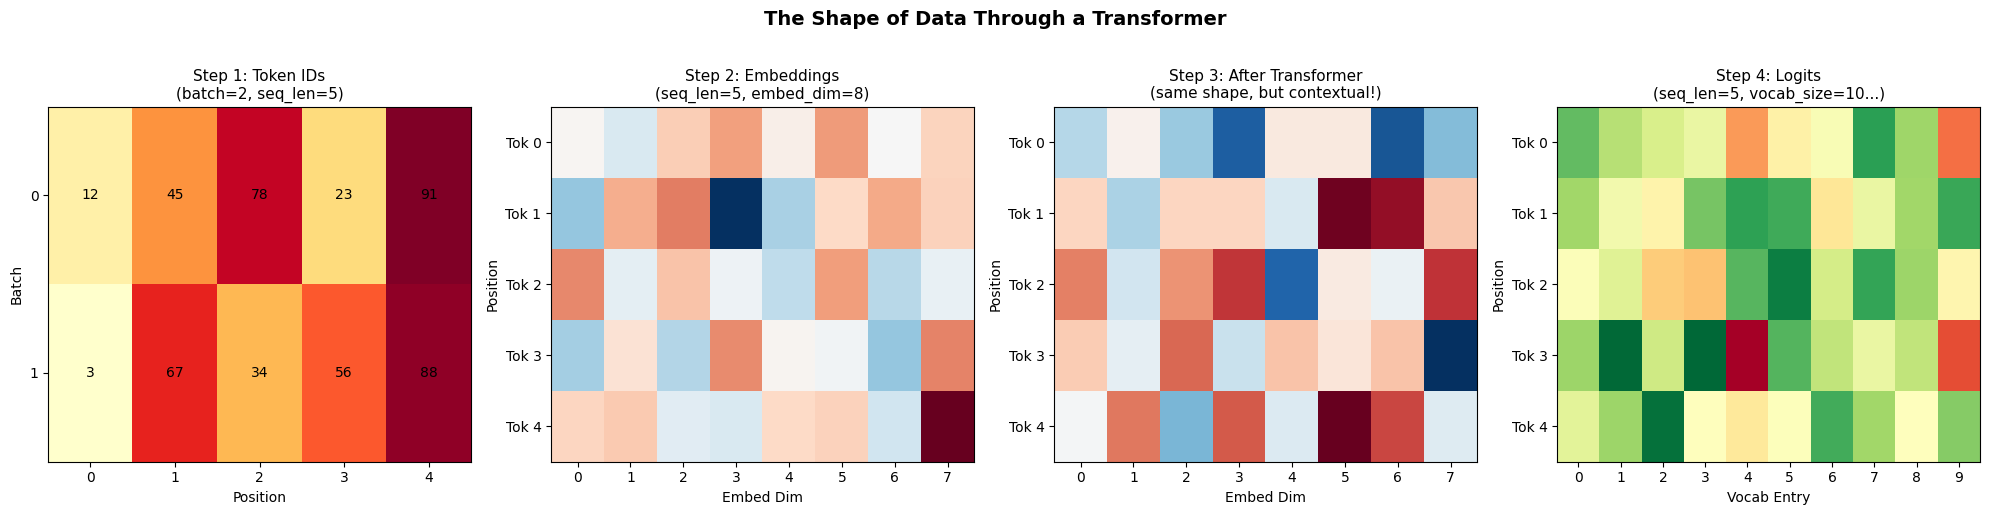

In [ ]:
# === VISUAL: Shape at each stage ===

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Stage 1: Token IDs
ax = axes[0]
data1 = np.array([[12, 45, 78, 23, 91], [3, 67, 34, 56, 88]])
im = ax.imshow(data1, cmap='YlOrRd', aspect='auto')
ax.set_title('Step 1: Token IDs\n(batch=2, seq_len=5)', fontsize=11)
ax.set_xlabel('Position'); ax.set_ylabel('Batch')
for i in range(2):
    for j in range(5):
        ax.text(j, i, str(data1[i, j]), ha='center', va='center', fontsize=10)
ax.set_xticks(range(5)); ax.set_yticks(range(2))

# Stage 2: Embeddings (show one sentence)
ax = axes[1]
data2 = embedded[0].detach().numpy()
im = ax.imshow(data2, cmap='RdBu', aspect='auto')
ax.set_title(f'Step 2: Embeddings\n(seq_len=5, embed_dim={d_model})', fontsize=11)
ax.set_xlabel('Embed Dim'); ax.set_ylabel('Position')
ax.set_xticks(range(d_model)); ax.set_yticks(range(5))
ax.set_yticklabels(['Tok 0', 'Tok 1', 'Tok 2', 'Tok 3', 'Tok 4'])

# Stage 3: After transformer (simulated)
ax = axes[2]
data3 = np.random.randn(5, d_model) * 0.5  # simulated contextual embeddings
im = ax.imshow(data3, cmap='RdBu', aspect='auto')
ax.set_title(f'Step 3: After Transformer\n(same shape, but contextual!)', fontsize=11)
ax.set_xlabel('Embed Dim'); ax.set_ylabel('Position')
ax.set_xticks(range(d_model)); ax.set_yticks(range(5))
ax.set_yticklabels(['Tok 0', 'Tok 1', 'Tok 2', 'Tok 3', 'Tok 4'])

# Stage 4: Logits
ax = axes[3]
data4 = np.random.randn(5, 10) * 2  # simulated logits (showing 10 of 100 vocab entries)
im = ax.imshow(data4, cmap='RdYlGn', aspect='auto')
ax.set_title(f'Step 4: Logits\n(seq_len=5, vocab_size=10...)', fontsize=11)
ax.set_xlabel('Vocab Entry'); ax.set_ylabel('Position')
ax.set_xticks(range(10)); ax.set_yticks(range(5))
ax.set_yticklabels(['Tok 0', 'Tok 1', 'Tok 2', 'Tok 3', 'Tok 4'])

plt.suptitle('The Shape of Data Through a Transformer', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/shape_journey.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 2.3 Static vs Contextual Embeddings — THE Big Distinction

This is one of the most asked questions: **Why are they called "contextual" vectors?**

The answer has to do with what happens BEFORE vs AFTER the transformer layers.

### Static Embeddings (Word2Vec, GloVe)
- One fixed vector per word, regardless of context
- "bank" always has the SAME vector whether it means "river bank" or "money bank"

### Contextual Embeddings (BERT, GPT, Transformers)
- The vector CHANGES based on surrounding words
- "bank" gets a DIFFERENT vector in "river bank" vs "bank account"

In [ ]:
# === DEMONSTRATE: STATIC vs CONTEXTUAL ===

print("=" * 65)
print("STATIC EMBEDDINGS: Same word → Same vector (always)")
print("=" * 65)
print()

# Simulating static embeddings (like Word2Vec)
static_embeddings = {
    "bank": np.array([0.5, 0.3, -0.2, 0.8]),   # one fixed vector
    "river": np.array([-0.3, 0.7, 0.5, 0.1]),
    "money": np.array([0.8, -0.5, 0.2, 0.6]),
}

sentence1 = "I walked along the river bank"     # bank = edge of river
sentence2 = "I deposited money in the bank"     # bank = financial institution

print(f"  Sentence 1: '{sentence1}'")
print(f"  Sentence 2: '{sentence2}'")
print()
print(f"  Static vector for 'bank': {static_embeddings['bank']}")
print(f"  It's the SAME vector in both sentences!")
print(f"  The model can't tell the difference between river bank and money bank.")
print(f"  ❌ This is a huge limitation.")

STATIC EMBEDDINGS: Same word → Same vector (always)

  Sentence 1: 'I walked along the river bank'
  Sentence 2: 'I deposited money in the bank'

  Static vector for 'bank': [ 0.5  0.3 -0.2  0.8]
  It's the SAME vector in both sentences!
  The model can't tell the difference between river bank and money bank.
  ❌ This is a huge limitation.


In [ ]:
# === NOW LET'S SEE CONTEXTUAL EMBEDDINGS IN ACTION ===
# We'll use a real BERT model to show how the same word gets different vectors

from transformers import AutoModel, AutoTokenizer
import torch

# Load BERT
model_name = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)
bert_model.eval()

def get_word_embedding(sentence, target_word, tokenizer, model):
    """
    Get the contextual embedding of a specific word in a sentence.

    Note: A word might be split into multiple tokens by the tokenizer.
    We average the token embeddings for that word.
    """
    # Tokenize
    inputs = tokenizer(sentence, return_tensors="pt", add_special_tokens=True)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # Get embeddings from the model
    with torch.no_grad():
        outputs = model(**inputs)

    # The last hidden state contains contextual embeddings
    # Shape: (batch=1, seq_len, hidden_dim=768)
    embeddings = outputs.last_hidden_state[0]  # (seq_len, 768)

    # Find the token(s) corresponding to our target word
    target_indices = []
    for i, token in enumerate(tokens):
        clean_token = token.replace('##', '')
        if target_word.startswith(clean_token) or clean_token == target_word:
            target_indices.append(i)

    if not target_indices:
        # Fallback: find any token that matches
        for i, token in enumerate(tokens):
            if target_word in token:
                target_indices.append(i)

    if target_indices:
        # Average embeddings if word was split into multiple tokens
        word_embedding = embeddings[target_indices].mean(dim=0)
    else:
        word_embedding = embeddings[1]  # fallback to first real token

    return word_embedding.numpy(), tokens


# Get 'bank' embeddings in different contexts
sentences = [
    ("I walked along the river bank in the morning", "bank", "river bank"),
    ("I deposited money at the bank downtown", "bank", "money bank"),
    ("The bank approved my loan application today", "bank", "loan bank"),
    ("We sat on the bank of the lake watching fish", "bank", "lake bank"),
]

print("=" * 65)
print("CONTEXTUAL EMBEDDINGS: Same word → Different vectors!")
print("=" * 65)
print()

bank_embeddings = []
labels = []

for sentence, target, label in sentences:
    emb, tokens = get_word_embedding(sentence, target, bert_tokenizer, bert_model)
    bank_embeddings.append(emb)
    labels.append(label)

    print(f"  '{sentence}'")
    print(f"    Tokens: {tokens}")
    print(f"    'bank' embedding (first 5 dims): [{', '.join(f'{v:.3f}' for v in emb[:5])}...]")
    print()

# Compare similarities
print("Cosine similarities between 'bank' in different contexts:")
print("-" * 55)
for i in range(len(bank_embeddings)):
    for j in range(i+1, len(bank_embeddings)):
        sim = cosine_similarity(bank_embeddings[i], bank_embeddings[j])
        print(f"  {labels[i]:12s} vs {labels[j]:12s}: {sim:.4f}")

print()
print("→ River bank and lake bank should be MORE similar to each other")
print("  than to money bank / loan bank.")
print("  The model understands that the SAME WORD has different meanings!")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CONTEXTUAL EMBEDDINGS: Same word → Different vectors!

  'I walked along the river bank in the morning'
    Tokens: ['[CLS]', 'i', 'walked', 'along', 'the', 'river', 'bank', 'in', 'the', 'morning', '[SEP]']
    'bank' embedding (first 5 dims): [0.209, -0.324, 0.180, -0.571, -0.391...]

  'I deposited money at the bank downtown'
    Tokens: ['[CLS]', 'i', 'deposited', 'money', 'at', 'the', 'bank', 'downtown', '[SEP]']
    'bank' embedding (first 5 dims): [0.566, -0.334, 0.149, -0.038, 0.812...]

  'The bank approved my loan application today'
    Tokens: ['[CLS]', 'the', 'bank', 'approved', 'my', 'loan', 'application', 'today', '[SEP]']
    'bank' embedding (first 5 dims): [0.242, -0.024, -0.051, -0.122, 1.197...]

  'We sat on the bank of the lake watching fish'
    Tokens: ['[CLS]', 'we', 'sat', 'on', 'the', 'bank', 'of', 'the', 'lake', 'watching', 'fish', '[SEP]']
    'bank' embedding (first 5 dims): [-0.044, -0.545, -0.203, 0.455, -0.817...]

Cosine similarities between 'bank' in di

In [ ]:
# === VISUALIZE: Where contextual embeddings come from ===

print("HOW CONTEXTUAL EMBEDDINGS ARE CREATED")
print("=" * 60)
print()
print("┌──────────────────────────────────────────────────────────────┐")
print("│                                                              │")
print("│  Text: 'I deposited money at the bank'                       │")
print("│                                                              │")
print("│  Step 1: Tokenize → [I, deposited, money, at, the, bank]    │")
print("│                                                              │")
print("│  Step 2: Embedding Lookup (STATIC at this point!)            │")
print("│          Each token → its row in the embedding table         │")
print("│          'bank' → [0.3, -0.1, ...] (same for all 'bank's)   │")
print("│                                                              │")
print("│  Step 3: Transformer Layers (THIS is where context happens!) │")
print("│          Self-attention lets 'bank' look at other tokens     │")
print("│          It sees 'money', 'deposited' → financial context    │")
print("│          'bank' vector CHANGES to encode financial meaning   │")
print("│                                                              │")
print("│  Step 4: Output embeddings are now CONTEXTUAL                │")
print("│          'bank' → [0.7, 0.4, ...] (financial meaning)       │")
print("│                                                              │")
print("│  If the sentence were 'sat on the river bank':              │")
print("│          'bank' would see 'river', 'sat on'                  │")
print("│          'bank' → [-0.2, 0.6, ...] (geographical meaning)   │")
print("│                                                              │")
print("└──────────────────────────────────────────────────────────────┘")
print()
print("KEY INSIGHT:")
print("  The embedding TABLE is static (same lookup for same token).")
print("  The OUTPUT of transformer layers is contextual.")
print("  Attention is the mechanism that CREATES context-dependence!")

HOW CONTEXTUAL EMBEDDINGS ARE CREATED

┌──────────────────────────────────────────────────────────────┐
│                                                              │
│  Text: 'I deposited money at the bank'                       │
│                                                              │
│  Step 1: Tokenize → [I, deposited, money, at, the, bank]    │
│                                                              │
│  Step 2: Embedding Lookup (STATIC at this point!)            │
│          Each token → its row in the embedding table         │
│          'bank' → [0.3, -0.1, ...] (same for all 'bank's)   │
│                                                              │
│  Step 3: Transformer Layers (THIS is where context happens!) │
│          Self-attention lets 'bank' look at other tokens     │
│          It sees 'money', 'deposited' → financial context    │
│          'bank' vector CHANGES to encode financial meaning   │
│                                                    

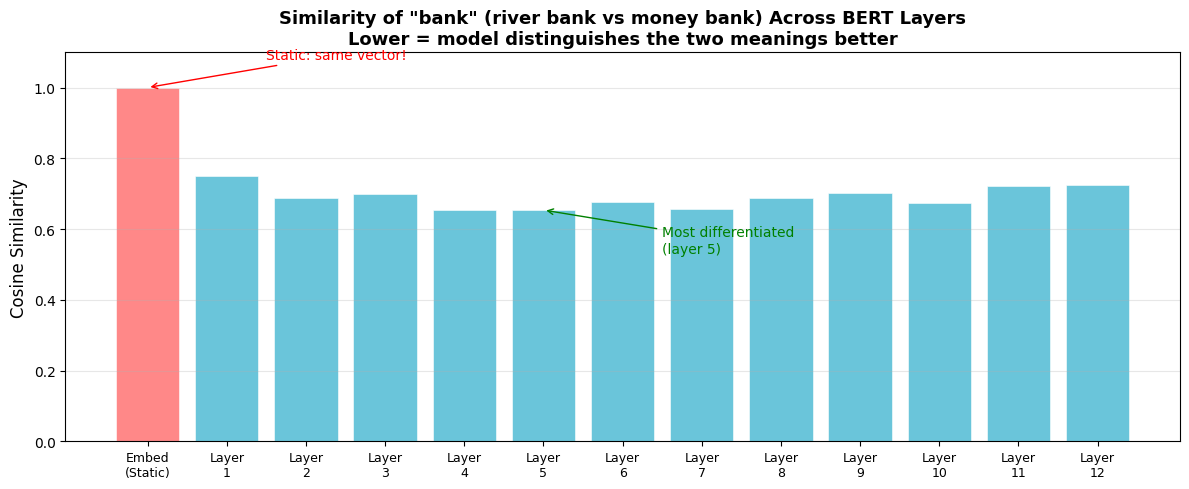

→ At Layer 0 (embedding table): 'bank' is nearly IDENTICAL in both sentences.
  As we go deeper, the transformer layers add context.
  By the later layers, the two 'bank' vectors are quite different!
  THIS is why we call them 'contextual' embeddings.


In [ ]:
# === DEEPER: Compare embeddings at different layers ===
# BERT has 12 layers. Let's see how 'bank' changes as it goes deeper.

def get_all_layer_embeddings(sentence, target_word, tokenizer, model):
    """Get the embedding of a word at EVERY layer of BERT."""
    inputs = tokenizer(sentence, return_tensors="pt", add_special_tokens=True)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # outputs.hidden_states is a tuple of (embedding_layer, layer_1, ..., layer_12)
    # Each has shape (1, seq_len, 768)

    # Find target word index
    target_idx = None
    for i, token in enumerate(tokens):
        if token == target_word:
            target_idx = i
            break

    if target_idx is None:
        target_idx = 1  # fallback

    # Collect embedding at each layer
    layer_embeddings = []
    for layer_output in outputs.hidden_states:
        layer_embeddings.append(layer_output[0, target_idx].numpy())

    return layer_embeddings


# Get 'bank' at all layers for two different contexts
layers_river = get_all_layer_embeddings(
    "I walked along the river bank", "bank", bert_tokenizer, bert_model
)
layers_money = get_all_layer_embeddings(
    "I deposited money at the bank", "bank", bert_tokenizer, bert_model
)

# Compute similarity at each layer
layer_similarities = []
for i in range(len(layers_river)):
    sim = cosine_similarity(layers_river[i], layers_money[i])
    layer_similarities.append(sim)

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))

layer_names = ['Embed\n(Static)'] + [f'Layer\n{i+1}' for i in range(12)]
colors = ['#FF6B6B'] + ['#45B7D1'] * 12
colors[0] = '#FF6B6B'  # static embedding

bars = ax.bar(range(13), layer_similarities, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(13))
ax.set_xticklabels(layer_names, fontsize=9)
ax.set_ylabel('Cosine Similarity', fontsize=12)
ax.set_title('Similarity of "bank" (river bank vs money bank) Across BERT Layers\n'
             'Lower = model distinguishes the two meanings better', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

# Annotate
ax.annotate('Static: same vector!', xy=(0, layer_similarities[0]),
           xytext=(1.5, layer_similarities[0] + 0.08),
           arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

min_layer = np.argmin(layer_similarities)
ax.annotate(f'Most differentiated\n(layer {min_layer})',
           xy=(min_layer, layer_similarities[min_layer]),
           xytext=(min_layer + 1.5, layer_similarities[min_layer] - 0.12),
           arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')

plt.tight_layout()
plt.savefig('/tmp/contextual_layers.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ At Layer 0 (embedding table): 'bank' is nearly IDENTICAL in both sentences.")
print("  As we go deeper, the transformer layers add context.")
print("  By the later layers, the two 'bank' vectors are quite different!")
print("  THIS is why we call them 'contextual' embeddings.")

---

## 2.4 How Do Vectors Capture Semantic Meaning?

The famous example: **King - Man + Woman ≈ Queen**

Vectors encode meaning as **directions** in space. Let's see this with real embeddings.

In [ ]:
# === WORD RELATIONSHIPS AS VECTOR ARITHMETIC ===

# We'll use a set of words and get their BERT embeddings
# Then show that semantic relationships are encoded as directions

word_sentences = {
    # We put each word in a neutral sentence to get a reasonable embedding
    "king":    "The king ruled the kingdom wisely",
    "queen":   "The queen ruled the kingdom wisely",
    "man":     "The man walked down the street today",
    "woman":   "The woman walked down the street today",
    "boy":     "The boy played in the park today",
    "girl":    "The girl played in the park today",
    "paris":   "The city of paris is beautiful today",
    "france":  "The country of france is beautiful today",
    "tokyo":   "The city of tokyo is beautiful today",
    "japan":   "The country of japan is beautiful today",
    "cat":     "The cat sat on the mat quietly",
    "dog":     "The dog sat on the mat quietly",
    "kitten":  "The kitten sat on the mat quietly",
    "puppy":   "The puppy sat on the mat quietly",
}

# Get embeddings for each word
word_embeddings = {}
for word, sentence in word_sentences.items():
    emb, _ = get_word_embedding(sentence, word, bert_tokenizer, bert_model)
    word_embeddings[word] = emb

print(f"Collected embeddings for {len(word_embeddings)} words.")
print(f"Each embedding has {len(list(word_embeddings.values())[0])} dimensions.")

Collected embeddings for 14 words.
Each embedding has 768 dimensions.


In [ ]:
# === VECTOR ARITHMETIC: king - man + woman ≈ ? ===

def find_closest(target_vec, word_embeddings, exclude=None):
    """Find the word whose embedding is closest to target_vec."""
    best_word = None
    best_sim = -1
    for word, emb in word_embeddings.items():
        if exclude and word in exclude:
            continue
        sim = cosine_similarity(target_vec, emb)
        if sim > best_sim:
            best_sim = sim
            best_word = word
    return best_word, best_sim


print("VECTOR ARITHMETIC (analogies):")
print("=" * 60)
print()

analogies = [
    ("king", "man", "woman", "king - man + woman ≈ ?"),
    ("paris", "france", "japan", "paris - france + japan ≈ ?"),
    ("cat", "kitten", "puppy", "cat - kitten + puppy ≈ ?"),
]

for word_a, word_b, word_c, description in analogies:
    # Compute: A - B + C
    result_vec = word_embeddings[word_a] - word_embeddings[word_b] + word_embeddings[word_c]

    closest_word, similarity = find_closest(
        result_vec, word_embeddings,
        exclude={word_a, word_b, word_c}
    )

    print(f"  {description}")
    print(f"  Answer: {closest_word} (similarity: {similarity:.4f})")
    print()

print("→ The model learned that 'king' is to 'man' as 'queen' is to 'woman'.")
print("  These relationships emerge from training on billions of words.")
print("  Nobody programmed them — the model discovered them from patterns in text!")

VECTOR ARITHMETIC (analogies):

  king - man + woman ≈ ?
  Answer: queen (similarity: 0.8674)

  paris - france + japan ≈ ?
  Answer: tokyo (similarity: 0.8034)

  cat - kitten + puppy ≈ ?
  Answer: dog (similarity: 0.8127)

→ The model learned that 'king' is to 'man' as 'queen' is to 'woman'.
  These relationships emerge from training on billions of words.
  Nobody programmed them — the model discovered them from patterns in text!


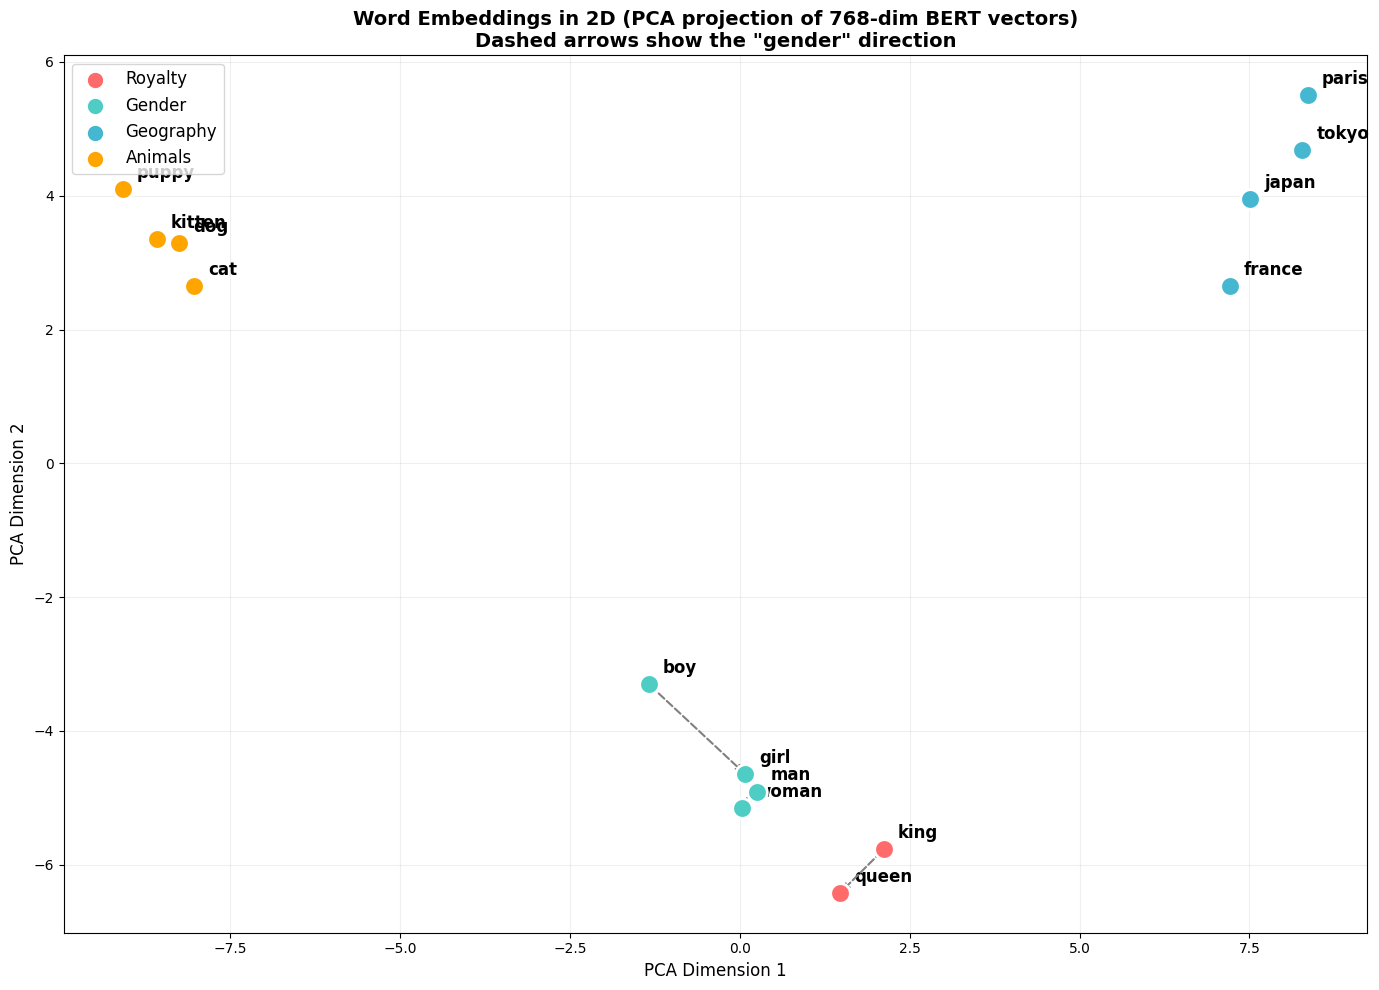

→ Words cluster by meaning (animals together, cities together, etc.)
  The 'gender direction' (dashed arrows) is roughly parallel for
  man→woman, king→queen, boy→girl.
  This is how vectors encode semantic relationships as directions!


In [ ]:
# === VISUALIZE ALL WORD EMBEDDINGS IN 2D ===

from sklearn.decomposition import PCA

words = list(word_embeddings.keys())
vectors = np.array([word_embeddings[w] for w in words])

# Reduce 768 dimensions to 2 for visualization
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Group words by category for coloring
groups = {
    "Royalty":    (["king", "queen"], "#FF6B6B"),
    "Gender":     (["man", "woman", "boy", "girl"], "#4ECDC4"),
    "Geography":  (["paris", "france", "tokyo", "japan"], "#45B7D1"),
    "Animals":    (["cat", "dog", "kitten", "puppy"], "#FFA500"),
}

fig, ax = plt.subplots(figsize=(14, 10))

for group_name, (group_words, color) in groups.items():
    for word in group_words:
        idx = words.index(word)
        ax.scatter(vectors_2d[idx, 0], vectors_2d[idx, 1],
                  c=color, s=200, zorder=5, edgecolors='white', linewidth=2)
        ax.annotate(word, (vectors_2d[idx, 0], vectors_2d[idx, 1]),
                   fontsize=12, fontweight='bold',
                   textcoords="offset points", xytext=(10, 8))
    ax.scatter([], [], c=color, s=100, label=group_name)

# Draw arrows for analogies
arrow_pairs = [
    ("man", "woman", "Gender direction"),
    ("king", "queen", ""),
    ("boy", "girl", ""),
]

for start, end, label in arrow_pairs:
    s_idx, e_idx = words.index(start), words.index(end)
    ax.annotate("", xy=vectors_2d[e_idx], xytext=vectors_2d[s_idx],
               arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, ls='--'))

ax.legend(fontsize=12, loc='upper left')
ax.set_title('Word Embeddings in 2D (PCA projection of 768-dim BERT vectors)\n'
             'Dashed arrows show the "gender" direction',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
ax.set_xlabel('PCA Dimension 1', fontsize=12)
ax.set_ylabel('PCA Dimension 2', fontsize=12)

plt.tight_layout()
plt.savefig('/tmp/word_embeddings_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Words cluster by meaning (animals together, cities together, etc.)")
print("  The 'gender direction' (dashed arrows) is roughly parallel for")
print("  man→woman, king→queen, boy→girl.")
print("  This is how vectors encode semantic relationships as directions!")

---

## 2.5 Embedding Shape Reference

A common source of confusion. Let's nail down the exact shapes.

In [ ]:
# === COMPLETE SHAPE REFERENCE ===

print("COMPLETE SHAPE REFERENCE")
print("=" * 75)
print()
print("One word/token embedding:")
print("  Shape: (embed_dim,)")
print("  Example: (768,) for BERT-base")
print("  → A single vector representing one token")
print()
print("One sentence (sequence of token embeddings):")
print("  Shape: (sequence_length, embed_dim)")
print("  Example: (128, 768) for a 128-token sentence in BERT")
print("  → A matrix where each ROW is one token's embedding")
print()
print("A batch of sentences:")
print("  Shape: (batch_size, sequence_length, embed_dim)")
print("  Example: (32, 128, 768) for a batch of 32 sentences")
print("  → A 3D tensor: batch_size × seq_len × embed_dim")
print()
print("The embedding TABLE itself:")
print("  Shape: (vocab_size, embed_dim)")
print("  Example: (30522, 768) for BERT-base")
print("  → Row i = the embedding vector for token ID i")
print()

print("-" * 75)
print("REAL MODEL DIMENSIONS:")
print("-" * 75)

models = [
    ("BERT-base",     30522, 768,   12, 12,  "110M"),
    ("BERT-large",    30522, 1024,  24, 16,  "340M"),
    ("GPT-2 Small",   50257, 768,   12, 12,  "124M"),
    ("GPT-2 XL",      50257, 1600,  48, 25,  "1.5B"),
    ("GPT-3",         50257, 12288, 96, 96,  "175B"),
    ("Llama-2 7B",    32000, 4096,  32, 32,  "7B"),
    ("Llama-2 70B",   32000, 8192,  80, 64,  "70B"),
]

print(f"{'Model':<16} {'Vocab':>8} {'Embed Dim':>10} {'Layers':>7} {'Heads':>6} {'Params':>8}")
for name, vocab, dim, layers, heads, params in models:
    print(f"{name:<16} {vocab:>8,} {dim:>10,} {layers:>7} {heads:>6} {params:>8}")

print()
print("→ The embedding dimension determines the 'richness' of representation.")
print("  768 dims = 768 learned features for each token.")
print("  12288 dims (GPT-3) = much more expressive but needs much more data.")

COMPLETE SHAPE REFERENCE

One word/token embedding:
  Shape: (embed_dim,)
  Example: (768,) for BERT-base
  → A single vector representing one token

One sentence (sequence of token embeddings):
  Shape: (sequence_length, embed_dim)
  Example: (128, 768) for a 128-token sentence in BERT
  → A matrix where each ROW is one token's embedding

A batch of sentences:
  Shape: (batch_size, sequence_length, embed_dim)
  Example: (32, 128, 768) for a batch of 32 sentences
  → A 3D tensor: batch_size × seq_len × embed_dim

The embedding TABLE itself:
  Shape: (vocab_size, embed_dim)
  Example: (30522, 768) for BERT-base
  → Row i = the embedding vector for token ID i

---------------------------------------------------------------------------
REAL MODEL DIMENSIONS:
---------------------------------------------------------------------------
Model               Vocab  Embed Dim  Layers  Heads   Params
BERT-base          30,522        768      12     12     110M
BERT-large         30,522      1,024

---

# PART 3: When Does Each Step Happen?

## 3.1 Training vs Inference — The Complete Picture

This is a critical question: **Do we tokenize and vectorize at training or inference?**

**Answer: BOTH.** But with an important distinction.

In [ ]:
print("TOKENIZATION & VECTORIZATION: Training vs Inference")
print("=" * 70)
print()

print("┌─────────────────────────────────────────────────────────────────────┐")
print("│                        TRAINING TIME                               │")
print("├─────────────────────────────────────────────────────────────────────┤")
print("│                                                                     │")
print("│  1. TOKENIZER TRAINING (one-time, before model training)            │")
print("│     - Run BPE on training corpus to learn merge rules               │")
print("│     - Build vocabulary (which subwords exist)                        │")
print("│     - This determines HOW text gets split into tokens               │")
print("│     - Done ONCE. Saved to disk. Never changes.                      │")
print("│                                                                     │")
print("│  2. TOKENIZATION (every training step)                              │")
print("│     - Apply learned merge rules to training text                    │")
print("│     - Text → Token IDs                                              │")
print("│     - Usually pre-processed before training starts                  │")
print("│                                                                     │")
print("│  3. EMBEDDING LOOKUP (every training step)                          │")
print("│     - Token IDs → Vectors (lookup from embedding table)             │")
print("│     - Embedding table is RANDOMLY INITIALIZED                       │")
print("│     - Gets UPDATED during training (it's learnable)                 │")
print("│                                                                     │")
print("│  4. TRANSFORMER LAYERS (every training step)                        │")
print("│     - Static embeddings → Contextual embeddings                     │")
print("│     - Weights get UPDATED by backpropagation                        │")
print("│                                                                     │")
print("│  5. LOSS + BACKPROP + UPDATE                                        │")
print("│     - All weights (including embeddings) get adjusted               │")
print("│                                                                     │")
print("└─────────────────────────────────────────────────────────────────────┘")
print()
print("┌─────────────────────────────────────────────────────────────────────┐")
print("│                        INFERENCE TIME                               │")
print("├─────────────────────────────────────────────────────────────────────┤")
print("│                                                                     │")
print("│  1. TOKENIZATION (every request)                                    │")
print("│     - Apply the SAME merge rules learned during training            │")
print("│     - Text → Token IDs (identical process)                          │")
print("│                                                                     │")
print("│  2. EMBEDDING LOOKUP (every request)                                │")
print("│     - Token IDs → Vectors (from FROZEN embedding table)             │")
print("│     - No updates — just lookup                                      │")
print("│                                                                     │")
print("│  3. TRANSFORMER LAYERS (every request)                              │")
print("│     - Static embeddings → Contextual embeddings                     │")
print("│     - Weights are FROZEN — no learning happens                      │")
print("│                                                                     │")
print("│  4. OUTPUT (next token prediction)                                  │")
print("│     - No backprop, no updates                                       │")
print("│                                                                     │")
print("└─────────────────────────────────────────────────────────────────────┘")
print()
print("TL;DR:")
print("  - Tokenizer rules: learned once, used at both training and inference")
print("  - Tokenization: happens at BOTH training and inference (same process)")
print("  - Embedding lookup: happens at BOTH (but only UPDATED during training)")
print("  - Contextual vectors: created at BOTH (but only LEARNED during training)")

TOKENIZATION & VECTORIZATION: Training vs Inference

┌─────────────────────────────────────────────────────────────────────┐
│                        TRAINING TIME                               │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. TOKENIZER TRAINING (one-time, before model training)            │
│     - Run BPE on training corpus to learn merge rules               │
│     - Build vocabulary (which subwords exist)                        │
│     - This determines HOW text gets split into tokens               │
│     - Done ONCE. Saved to disk. Never changes.                      │
│                                                                     │
│  2. TOKENIZATION (every training step)                              │
│     - Apply learned merge rules to training text                    │
│     - Text → Token IDs                                              │
│     - Usu

/tmp/ipykernel_960/423754487.py:63: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_960/423754487.py:64: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/tmp/training_vs_inference.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


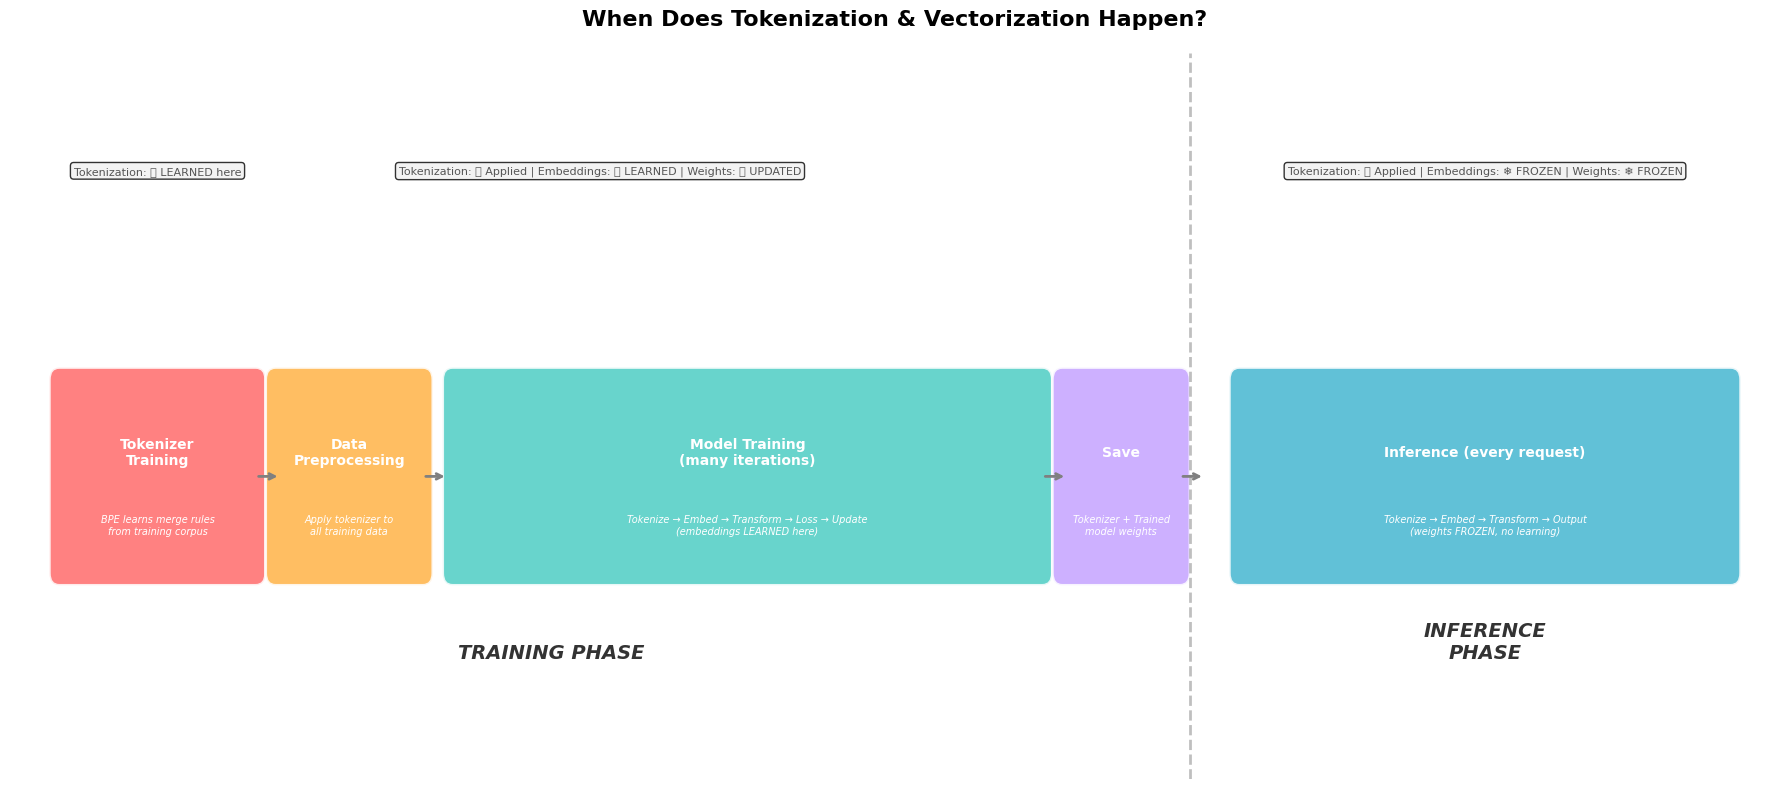

In [ ]:
# === VISUAL TIMELINE ===

fig, ax = plt.subplots(figsize=(18, 8))

# Define the timeline
phases = [
    # (x_start, width, y, label, sublabel, color)
    # Phase 0: Tokenizer Training
    (0, 2, 4, "Tokenizer\nTraining", "BPE learns merge rules\nfrom training corpus", "#FF6B6B"),
    # Phase 1: Data Preprocessing
    (2.2, 1.5, 4, "Data\nPreprocessing", "Apply tokenizer to\nall training data", "#FFB347"),
    # Phase 2: Model Training (repeated)
    (4, 6, 4, "Model Training\n(many iterations)", "Tokenize → Embed → Transform → Loss → Update\n(embeddings LEARNED here)", "#4ECDC4"),
    # Phase 3: Save
    (10.2, 1.2, 4, "Save", "Tokenizer + Trained\nmodel weights", "#C5A3FF"),
    # Phase 4: Inference
    (12, 5, 4, "Inference (every request)", "Tokenize → Embed → Transform → Output\n(weights FROZEN, no learning)", "#45B7D1"),
]

for x, w, y, label, sublabel, color in phases:
    rect = mpatches.FancyBboxPatch(
        (x, y - 0.8), w, 1.6,
        boxstyle="round,pad=0.1", facecolor=color, edgecolor='white',
        alpha=0.85, linewidth=2
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + 0.2, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    ax.text(x + w/2, y - 0.4, sublabel, ha='center', va='center',
            fontsize=7, color='white', style='italic')

# Arrows
arrow_xs = [2.0, 3.7, 10.0, 11.4]
for x in arrow_xs:
    ax.annotate('', xy=(x + 0.25, 4), xytext=(x, 4),
               arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# Labels
ax.text(5, 2.5, "TRAINING PHASE", fontsize=14, fontweight='bold',
        ha='center', color='#333', style='italic')
ax.text(14.5, 2.5, "INFERENCE\nPHASE", fontsize=14, fontweight='bold',
        ha='center', color='#333', style='italic')

# Dividing line
ax.axvline(x=11.5, color='gray', linestyle='--', alpha=0.5, linewidth=2)

# What happens at each step
details = [
    (1.0, 6.5, "Tokenization: ✅ LEARNED here"),
    (5.5, 6.5, "Tokenization: ✅ Applied | Embeddings: ✅ LEARNED | Weights: ✅ UPDATED"),
    (14.5, 6.5, "Tokenization: ✅ Applied | Embeddings: ❄️ FROZEN | Weights: ❄️ FROZEN"),
]
for x, y, text in details:
    ax.text(x, y, text, fontsize=8, ha='center', color='#555',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))

ax.set_xlim(-0.5, 17.5)
ax.set_ylim(1.5, 7.5)
ax.set_title('When Does Tokenization & Vectorization Happen?',
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.savefig('/tmp/training_vs_inference.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# === DEMO: Same tokenizer, training vs inference ===

import torch
import torch.nn as nn

print("DEMO: Tokenization at Training vs Inference")
print("=" * 55)
print()

# Simulate a tiny model
vocab_size = 100
embed_dim = 16

embedding = nn.Embedding(vocab_size, embed_dim)

# Capture initial embedding for token 42
initial_vec = embedding.weight[42].detach().clone()

print("Before training:")
print(f"  Embedding for token 42: [{', '.join(f'{v:.3f}' for v in initial_vec[:6])}...]")
print()

# Simulate training: embedding weights get updated via gradient descent
optimizer = torch.optim.SGD(embedding.parameters(), lr=0.1)

for step in range(5):
    # Simulated forward pass
    token_ids = torch.tensor([42, 17, 85])
    vecs = embedding(token_ids)

    # Simulated loss and backprop
    fake_loss = vecs.sum()  # dummy loss
    optimizer.zero_grad()
    fake_loss.backward()
    optimizer.step()  # THIS updates the embedding weights!

trained_vec = embedding.weight[42].detach().clone()

print("After training:")
print(f"  Embedding for token 42: [{', '.join(f'{v:.3f}' for v in trained_vec[:6])}...]")
print()

# Check if they changed
diff = (trained_vec - initial_vec).abs().mean().item()
print(f"  Average change per dimension: {diff:.4f}")
print(f"  → The embedding CHANGED during training!")
print()

# At inference: same lookup, but no updates
print("At inference time:")
with torch.no_grad():  # no gradient tracking
    inference_vec = embedding(torch.tensor([42]))
    print(f"  Embedding for token 42: [{', '.join(f'{v:.3f}' for v in inference_vec[0][:6])}...]")
    print(f"  Same as trained vector: {torch.allclose(inference_vec[0], trained_vec)}")
    print(f"  → At inference, we use the TRAINED embeddings (frozen, no updates)")

DEMO: Tokenization at Training vs Inference

Before training:
  Embedding for token 42: [-0.337, 0.080, 0.657, -0.437, -0.629, -1.246...]

After training:
  Embedding for token 42: [-0.837, -0.420, 0.157, -0.937, -1.129, -1.746...]

  Average change per dimension: 0.5000
  → The embedding CHANGED during training!

At inference time:
  Embedding for token 42: [-0.837, -0.420, 0.157, -0.937, -1.129, -1.746...]
  Same as trained vector: True
  → At inference, we use the TRAINED embeddings (frozen, no updates)


---

## 2.6 Sentence/Document Embeddings — Beyond Words

So far we've talked about token-level embeddings. But in practice (RAG, semantic search, etc.), we often need a **single vector for an entire sentence or document**.

How? Several strategies:

In [ ]:
# === SENTENCE EMBEDDINGS ===

def get_sentence_embedding(sentence, tokenizer, model, strategy="mean"):
    """
    Get a single vector for an entire sentence.

    Strategies:
    - 'cls': Use the [CLS] token (BERT's special token designed for this)
    - 'mean': Average all token embeddings (often works better!)
    """
    inputs = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        outputs = model(**inputs)

    # last_hidden_state shape: (1, seq_len, 768)
    if strategy == "cls":
        # Use the first token ([CLS]) as the sentence representation
        return outputs.last_hidden_state[0, 0, :].numpy()
    elif strategy == "mean":
        # Average all token embeddings (ignoring padding)
        attention_mask = inputs['attention_mask'][0].unsqueeze(-1)  # (seq_len, 1)
        masked = outputs.last_hidden_state[0] * attention_mask     # zero out padding
        return (masked.sum(dim=0) / attention_mask.sum()).numpy()   # mean of real tokens


# Compare similar and different sentences
sentence_pairs = [
    ("I love machine learning and artificial intelligence",
     "Deep learning and AI are fascinating to me",
     "Similar meaning"),

    ("I love machine learning and artificial intelligence",
     "The weather is sunny and warm today",
     "Very different meaning"),

    ("The bank is by the river",
     "The bank approved my loan",
     "Same word, different context"),

    ("She doesn't like chocolate",
     "She hates chocolate",
     "Same meaning, different words"),

    ("The movie was not bad at all",
     "The movie was actually quite good",
     "Negation with similar meaning"),
]

print("SENTENCE SIMILARITY (using mean pooled BERT embeddings):")
print("=" * 65)

for sent1, sent2, label in sentence_pairs:
    emb1 = get_sentence_embedding(sent1, bert_tokenizer, bert_model)
    emb2 = get_sentence_embedding(sent2, bert_tokenizer, bert_model)
    sim = cosine_similarity(emb1, emb2)

    bar = "█" * int(sim * 30)
    print(f"\n  [{label}]")
    print(f"  A: '{sent1}'")
    print(f"  B: '{sent2}'")
    print(f"  Similarity: {sim:.4f}  {bar}")

print("\n→ This is the foundation of semantic search and RAG!")
print("  Embed the query, embed the documents, find the closest match.")

SENTENCE SIMILARITY (using mean pooled BERT embeddings):

  [Similar meaning]
  A: 'I love machine learning and artificial intelligence'
  B: 'Deep learning and AI are fascinating to me'
  Similarity: 0.8116  ████████████████████████

  [Very different meaning]
  A: 'I love machine learning and artificial intelligence'
  B: 'The weather is sunny and warm today'
  Similarity: 0.5302  ███████████████

  [Same word, different context]
  A: 'The bank is by the river'
  B: 'The bank approved my loan'
  Similarity: 0.5973  █████████████████

  [Same meaning, different words]
  A: 'She doesn't like chocolate'
  B: 'She hates chocolate'
  Similarity: 0.8339  █████████████████████████

  [Negation with similar meaning]
  A: 'The movie was not bad at all'
  B: 'The movie was actually quite good'
  Similarity: 0.8756  ██████████████████████████

→ This is the foundation of semantic search and RAG!
  Embed the query, embed the documents, find the closest match.


In [ ]:
# === MINI RAG DEMO: Find the most relevant document ===

# Imagine these are chunks from a knowledge base
documents = [
    "Python is a popular programming language used for web development and data science.",
    "The Eiffel Tower is a famous landmark located in Paris, France.",
    "Machine learning models learn patterns from data to make predictions.",
    "The Great Wall of China is one of the most impressive structures ever built.",
    "Neural networks are inspired by the structure of the human brain.",
    "Cats are independent pets that have been domesticated for thousands of years.",
    "Transformers use self-attention to process sequences of text efficiently.",
    "The Amazon rainforest is the largest tropical forest in the world.",
]

# Pre-compute embeddings for all documents (in production, you'd store these in a vector DB)
doc_embeddings = []
for doc in documents:
    emb = get_sentence_embedding(doc, bert_tokenizer, bert_model)
    doc_embeddings.append(emb)

# Query
query = "How do attention mechanisms work in NLP?"
query_emb = get_sentence_embedding(query, bert_tokenizer, bert_model)

# Find most similar documents
similarities = [cosine_similarity(query_emb, doc_emb) for doc_emb in doc_embeddings]

# Sort by similarity
ranked = sorted(enumerate(similarities), key=lambda x: -x[1])

print(f"Query: '{query}'")
print()
print("Ranked documents by relevance:")
print("-" * 75)
for rank, (idx, sim) in enumerate(ranked):
    bar = "█" * int(sim * 25)
    marker = "⭐" if rank < 3 else "  "
    print(f"  {marker} {sim:.4f} {bar}")
    print(f"      '{documents[idx]}'")

print()
print("→ The transformer and neural network docs rank highest!")
print("  In real RAG: embed query → search vector DB → pass top docs to LLM → generate answer")

Query: 'How do attention mechanisms work in NLP?'

Ranked documents by relevance:
---------------------------------------------------------------------------
  ⭐ 0.7408 ██████████████████
      'Neural networks are inspired by the structure of the human brain.'
  ⭐ 0.7396 ██████████████████
      'Machine learning models learn patterns from data to make predictions.'
  ⭐ 0.7196 █████████████████
      'Transformers use self-attention to process sequences of text efficiently.'
     0.5167 ████████████
      'Python is a popular programming language used for web development and data science.'
     0.4711 ███████████
      'Cats are independent pets that have been domesticated for thousands of years.'
     0.4526 ███████████
      'The Amazon rainforest is the largest tropical forest in the world.'
     0.4517 ███████████
      'The Great Wall of China is one of the most impressive structures ever built.'
     0.4083 ██████████
      'The Eiffel Tower is a famous landmark located in Paris

---

# 🎯 Summary: Everything You Need to Know

### Tokenization

| Question | Answer |
|---|---|
| **Why tokenize?** | Models need numbers. Tokenization converts text to integer IDs. |
| **Why not characters?** | Too many tokens per sentence → slow, hard to learn meaning |
| **Why not whole words?** | Vocabulary too large, can't handle unknown words |
| **Why subwords (BPE)?** | Best of both: manageable vocab, handles any text, captures morphology |
| **How does BPE work?** | Start with characters, iteratively merge most frequent pairs |
| **When do we tokenize?** | Both training AND inference (same merge rules) |
| **Is the tokenizer learned?** | Yes, BPE merge rules are learned from training data (once) |

### Vectorization (Embeddings)

| Question | Answer |
|---|---|
| **What is an embedding?** | A dense vector (list of numbers) representing a token |
| **How do they capture meaning?** | Trained on billions of words — similar words get similar vectors |
| **What's the shape?** | One token: `(embed_dim,)`. One sentence: `(seq_len, embed_dim)`. Batch: `(batch, seq_len, embed_dim)` |
| **Static vs Contextual?** | Static = same vector always. Contextual = changes based on surrounding words. |
| **Where does context come from?** | The attention mechanism in transformer layers |
| **When does vectorization happen?** | Both training AND inference. Embeddings are LEARNED during training, FROZEN at inference. |
| **What about sentence embeddings?** | Pool token embeddings (mean or [CLS]) → used for search, RAG, classification |